# Hungarian Election Prediction 2026 | Andrási Kristóf - exploratory analysis


### Imports

This block loads the packages used in the notebook.


In [1]:
# this block loads the packages used in the notebook.
import importlib
import subprocess
import sys

# check and install missing packages
def ensure_packages(packages):
    # packages is a list of package names as strings
    for pkg in packages:
        try:
            # try to import the package
            importlib.import_module(pkg)
        except ImportError:
            # if import fails, install with pip
            print(f"{pkg} not found, installing...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
            print(f"{pkg} installed.")

# first make sure the core packages are available
ensure_packages(["pandas",
                 "numpy",
                 "openpyxl",
                 "matplotlib",
                 "re",
                 "xlrd"])

# now import the packages you actually want to use
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import re
import numpy as np

### Working Directory

This block sets the main project paths so file loading works the same way each time.


In [2]:
# this block sets the main project paths so file loading works the same way each time.
def find_project_root(start_path=None):
    start_path = Path.cwd().resolve() if start_path is None else Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "scripts" / "final_final_scripts").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root from the current working directory.")

here = Path.cwd().resolve()
project_root = find_project_root(here)
data_dir = project_root / "data" / "TokaGabor"

print("here:", here)
print("project_root:", project_root)
print("data_dir:", data_dir)


here: /Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/scripts/final_final_scripts
project_root: /Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions
data_dir: /Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/data/TokaGabor


Interpretation. The printed paths should point to this election project. If they do not, the later loading steps can fail.


### Dataframe import

This block loads the prepared tables written by notebook 01.


In [3]:
# this block loads the prepared tables written by notebook 01.
# recreate output folder path
created_dir = data_dir.parent / "created"

# 1) statistics.csv → final_statistics_oevk
final_statistics_oevk = pd.read_csv(
    created_dir / "statistics.csv"
)

# 2) oevk_results.csv → final_results_oevk_party
final_results_oevk_party = pd.read_csv(
    created_dir / "oevk_results.csv"
)

# 3) polls.csv → polls
polls = pd.read_csv(
    created_dir / "polls.csv"
)

# 4) global_results.csv → mandates_all_combined
mandates_all_combined = pd.read_csv(
    created_dir / "global_results.csv"
)

# optional: clean up helper path variable
for var in ["created_dir"]:
    if var in locals():
        del locals()[var]
del var

### Descriptive stats

This block builds basic descriptive statistics for the prepared district table.


In [4]:
# this block builds basic descriptive statistics for the prepared district table.
import pandas as pd
import numpy as np

# use your dataframe here
df = final_statistics_oevk.copy()

# identify numeric and non-numeric columns
numeric_cols = df.select_dtypes(include="number").columns
categorical_cols = df.columns.difference(numeric_cols)

# numeric summary 
numeric_summary = df[numeric_cols].describe().T  # count, mean, std, min, 25%, 50%, 75%, max

# add missing count and share
numeric_summary["missing"] = df[numeric_cols].isna().sum()
numeric_summary["missing_share"] = numeric_summary["missing"] / len(df)

# reorder columns for readability
numeric_summary = numeric_summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max", "missing", "missing_share"]
]

# categorical summary 
cat_rows = []

for col in categorical_cols:
    s = df[col]
    n = len(s)
    n_missing = s.isna().sum()
    n_unique = s.nunique(dropna=True)

    mode_vals = s.mode(dropna=True)
    if len(mode_vals) > 0:
        top_val = mode_vals.iloc[0]
        top_freq = (s == top_val).sum()
    else:
        top_val = pd.NA
        top_freq = 0

    cat_rows.append({
        "column": col,
        "n_unique": n_unique,
        "top": top_val,
        "top_freq": top_freq,
        "missing": n_missing,
        "missing_share": n_missing / n
    })

categorical_summary = (
    pd.DataFrame(cat_rows)
    .set_index("column")
    .sort_index()
)


# clean up helper variables, keep only the two summaries
for var in [
    "df",
    "numeric_cols",
    "categorical_cols",
    "cat_rows",
    "s",
    "n",
    "n_missing",
    "n_unique",
    "mode_vals",
    "top_val",
    "top_freq",
]:
    if var in locals():
        del locals()[var]
del var,col

### EP elections – vote share vs seat share by party

This block compares EP vote shares and seat shares by party.


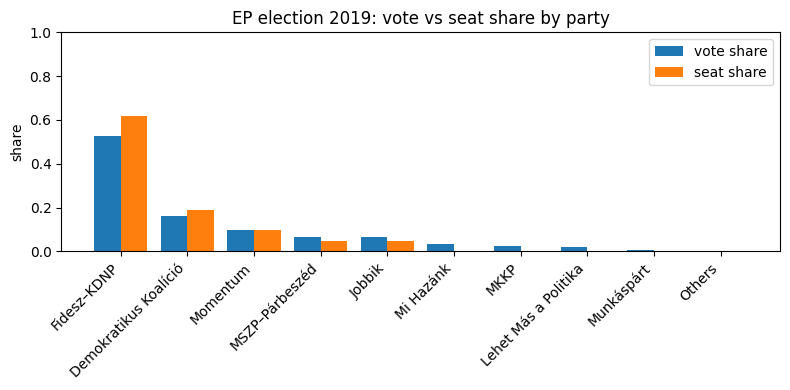

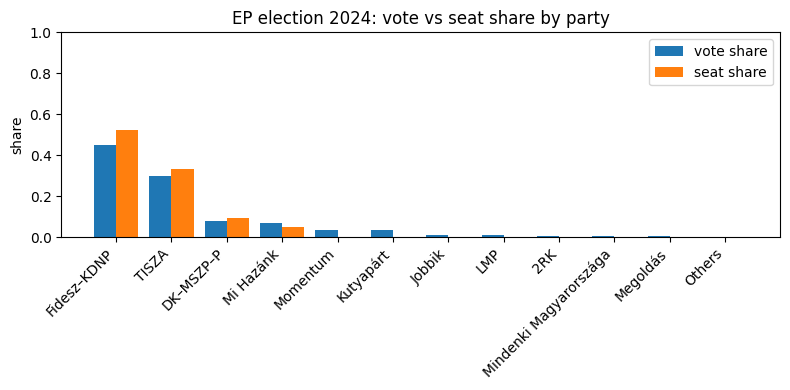

In [5]:
# this block compares EP vote shares and seat shares by party.
# work on a copy
ep = mandates_all_combined.copy()

# keep only EP elections
ep = ep[ep["election_type"] == "ep"].copy()

# drop possible total summary rows if they exist (party = 'Összesen' or similar)
ep = ep[~ep["party"].str.contains("Összesen", case=False, na=False)].copy()

# compute seat share within each ep election
ep["seat_share"] = ep.groupby("year")["seats"].transform(
    lambda x: x / x.sum()
)

# compute vote share within each ep election
# if 'list_votes' is filled, use that; otherwise fall back to 'percent' / 100
if ep["list_votes"].notna().any():
    ep["vote_share"] = ep.groupby("year")["list_votes"].transform(
        lambda x: x / x.sum()
    )
else:
    ep["vote_share"] = ep["percent"] / 100.0

# simple, consistent order by vote share
ep = ep.sort_values(["year", "vote_share"], ascending=[True, False])

years_ep = sorted(ep["year"].unique())

for y in years_ep:
    sub = ep[ep["year"] == y].copy()

    x = np.arange(len(sub))
    width = 0.4

    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, sub["vote_share"], width, label="vote share")
    plt.bar(x + width/2, sub["seat_share"], width, label="seat share")

    plt.xticks(x, sub["party"], rotation=45, ha="right")
    plt.ylabel("share")
    plt.ylim(0, 1)
    plt.title(f"EP election {y}: vote vs seat share by party")
    plt.legend()
    plt.tight_layout()
    plt.show()

# optional clean-up
for var in ["ep", "sub", "x", "width", "years_ep", "y"]:
    if var in locals():
        del locals()[var]
del var

Interpretation. Bigger gaps mean the election translated votes into seats less proportionally.


### OEVK-level block shares: gov / opp / opp_radical distributions

This block shows how district level block shares are distributed across elections.



=== 2018 – nat ===


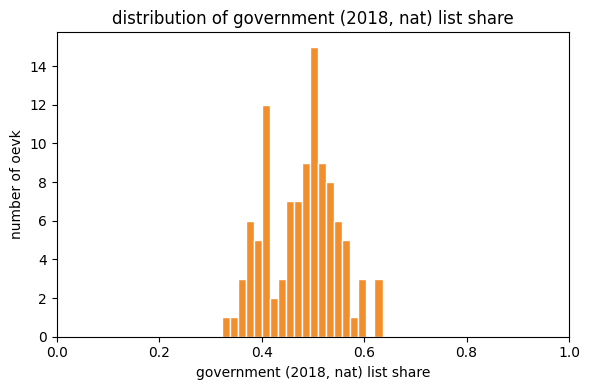


Summary for government (2018, nat) list share:
count    106.000
mean       0.479
std        0.068
min        0.323
25%        0.412
50%        0.489
75%        0.525
max        0.636
Name: gov_list_share, dtype: float64


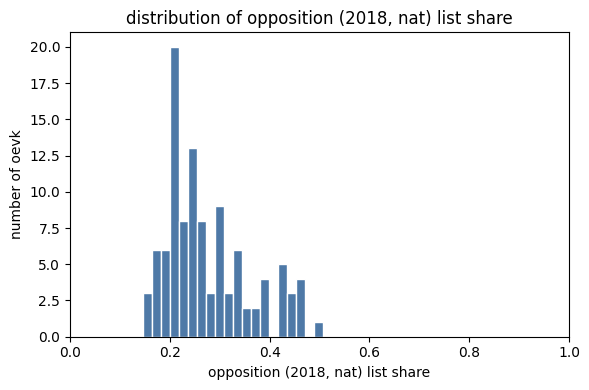


Summary for opposition (2018, nat) list share:
count    106.000
mean       0.277
std        0.086
min        0.147
25%        0.210
50%        0.252
75%        0.332
max        0.507
Name: opp_list_share, dtype: float64


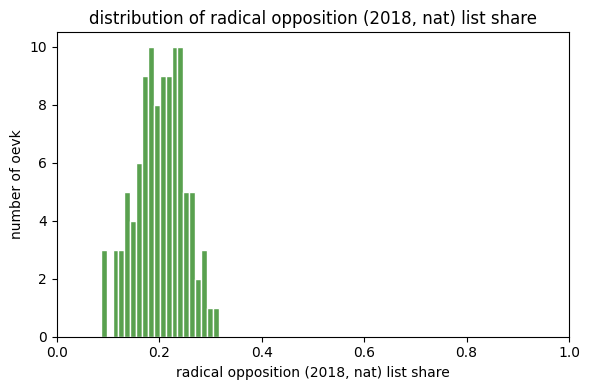


Summary for radical opposition (2018, nat) list share:
count    106.000
mean       0.201
std        0.049
min        0.086
25%        0.172
50%        0.203
75%        0.236
max        0.316
Name: opp_radical_list_share, dtype: float64

=== 2019 – ep ===


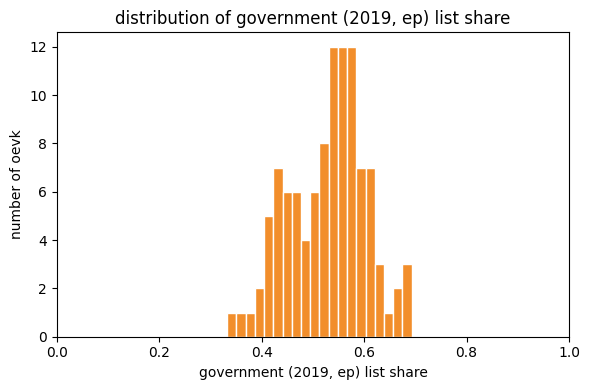


Summary for government (2019, ep) list share:
count    106.000
mean       0.529
std        0.076
min        0.333
25%        0.463
50%        0.538
75%        0.581
max        0.693
Name: gov_list_share, dtype: float64


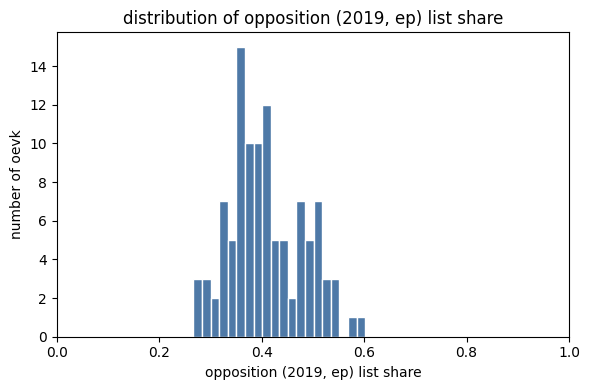


Summary for opposition (2019, ep) list share:
count    106.000
mean       0.408
std        0.072
min        0.267
25%        0.357
50%        0.396
75%        0.467
max        0.602
Name: opp_list_share, dtype: float64


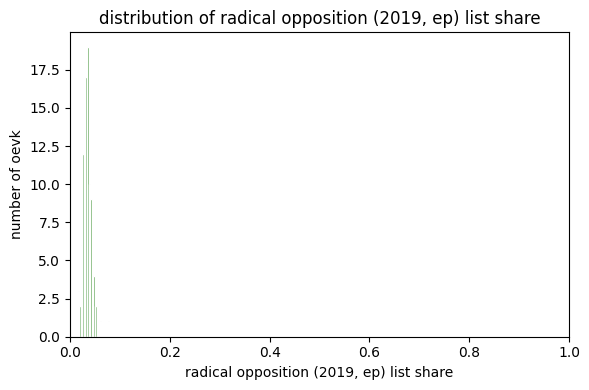


Summary for radical opposition (2019, ep) list share:
count    106.000
mean       0.034
std        0.009
min        0.015
25%        0.029
50%        0.033
75%        0.038
max        0.079
Name: opp_radical_list_share, dtype: float64

=== 2022 – nat ===


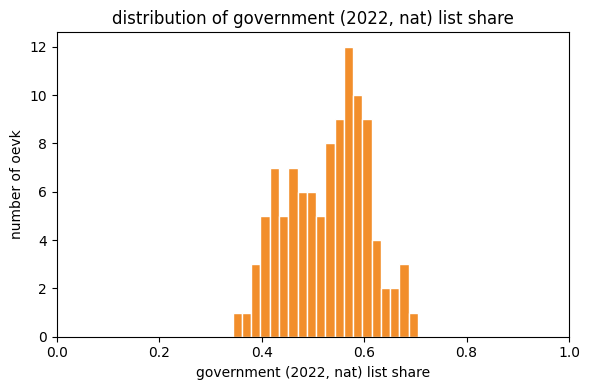


Summary for government (2022, nat) list share:
count    106.000
mean       0.528
std        0.080
min        0.343
25%        0.466
50%        0.541
75%        0.587
max        0.705
Name: gov_list_share, dtype: float64


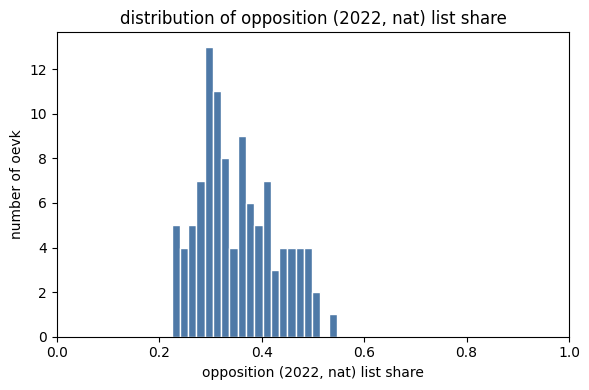


Summary for opposition (2022, nat) list share:
count    106.000
mean       0.353
std        0.076
min        0.224
25%        0.293
50%        0.337
75%        0.414
max        0.547
Name: opp_list_share, dtype: float64


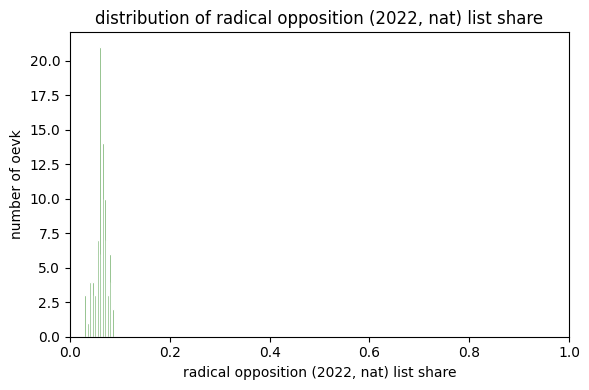


Summary for radical opposition (2022, nat) list share:
count    106.000
mean       0.062
std        0.013
min        0.028
25%        0.056
50%        0.061
75%        0.070
max        0.095
Name: opp_radical_list_share, dtype: float64

=== 2024 – ep ===


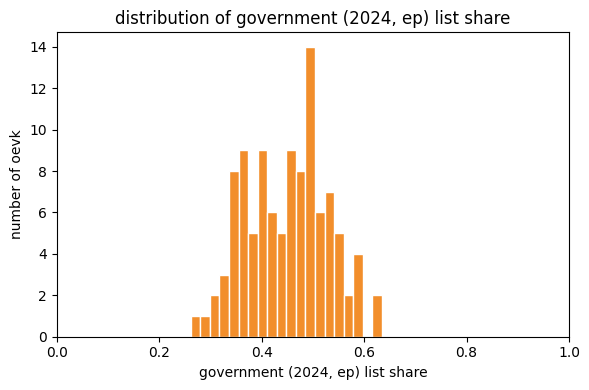


Summary for government (2024, ep) list share:
count    106.000
mean       0.448
std        0.081
min        0.261
25%        0.386
50%        0.455
75%        0.502
max        0.635
Name: gov_list_share, dtype: float64


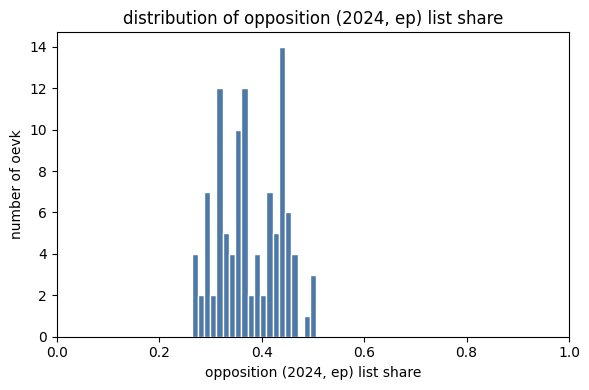


Summary for opposition (2024, ep) list share:
count    106.000
mean       0.377
std        0.060
min        0.263
25%        0.324
50%        0.367
75%        0.434
max        0.507
Name: opp_list_share, dtype: float64


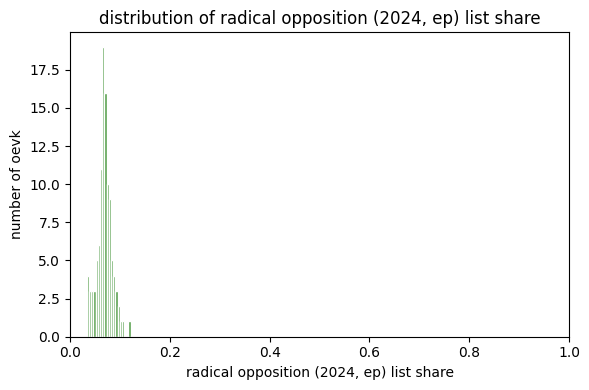


Summary for radical opposition (2024, ep) list share:
count    106.000
mean       0.069
std        0.015
min        0.034
25%        0.062
50%        0.068
75%        0.077
max        0.122
Name: opp_radical_list_share, dtype: float64


In [6]:
# this block shows how district level block shares are distributed across elections.
# work on a copy
df = final_results_oevk_party.copy()

# make sure list_votes and valid_list_total are numeric
df["list_votes"] = pd.to_numeric(df["list_votes"], errors="coerce")
df["valid_list_total"] = pd.to_numeric(df["valid_list_total"], errors="coerce")
df["cand_votes"] = pd.to_numeric(df["cand_votes"], errors="coerce")
df["valid_cand_total"] = pd.to_numeric(df["valid_cand_total"], errors="coerce")

# aggregate to oevk × year × election_type × party_block
block = (
    df
    .groupby(["year", "election_type", "oevk_id", "party_block"], as_index=False)
    .agg(
        list_votes=("list_votes", "sum"),
        cand_votes=("cand_votes", "sum"),
        valid_list_total=("valid_list_total", "first"),
        valid_cand_total=("valid_cand_total", "first"),
    )
)

# compute block-level shares
block["block_list_share"] = (
    block["list_votes"] / block["valid_list_total"].replace({0: np.nan})
)
block["block_cand_share"] = (
    block["cand_votes"] / block["valid_cand_total"].replace({0: np.nan})
)

# pivot to wide format: one row per year–election–oevk_id
list_wide = block.pivot(
    index=["year", "election_type", "oevk_id"],
    columns="party_block",
    values="block_list_share"
)

cand_wide = block.pivot(
    index=["year", "election_type", "oevk_id"],
    columns="party_block",
    values="block_cand_share"
)

# rename columns to something friendly
if "gov" in list_wide.columns:
    list_wide = list_wide.rename(columns={"gov": "gov_list_share"})
if "opp" in list_wide.columns:
    list_wide = list_wide.rename(columns={"opp": "opp_list_share"})
if "opp_radical" in list_wide.columns:
    list_wide = list_wide.rename(columns={"opp_radical": "opp_radical_list_share"})
if "other" in list_wide.columns:
    list_wide = list_wide.rename(columns={"other": "other_list_share"})

if "gov" in cand_wide.columns:
    cand_wide = cand_wide.rename(columns={"gov": "gov_cand_share"})
if "opp" in cand_wide.columns:
    cand_wide = cand_wide.rename(columns={"opp": "opp_cand_share"})
if "opp_radical" in cand_wide.columns:
    cand_wide = cand_wide.rename(columns={"opp_radical": "opp_radical_cand_share"})
if "other" in cand_wide.columns:
    cand_wide = cand_wide.rename(columns={"other": "other_cand_share"})

# merge list & cand back together
oevk_block_panel = (
    list_wide
    .reset_index()
    .merge(
        cand_wide.reset_index(),
        on=["year", "election_type", "oevk_id"],
        how="left",
        suffixes=("", "_canddup"),
    )
)

# drop any duplicate cols accidentally created
dup_cols = [c for c in oevk_block_panel.columns if c.endswith("_canddup")]
oevk_block_panel = oevk_block_panel.drop(columns=dup_cols)

# histograms for gov and opp list share by election

lims = [0, 1]

def hist_block_share(panel, col, title_prefix):
    """simple 1D histogram helper"""
    color_map = {
        "gov_list_share": "#f28e2b",
        "opp_list_share": "#4e79a7",
        "opp_radical_list_share": "#59a14f",
        "other_list_share": "#9c9c9c",
    }
    plt.figure(figsize=(6, 4))
    plt.hist(panel[col].dropna(), bins=20, color=color_map.get(col, "#9c9c9c"), edgecolor="white")
    plt.xlabel(f"{title_prefix} list share")
    plt.ylabel("number of oevk")
    plt.title(f"distribution of {title_prefix} list share")
    plt.xlim(lims)
    plt.tight_layout()
    plt.show()
    print(f"\nSummary for {title_prefix} list share:")
    print(panel[col].describe().round(3))


# loop over elections
for (y, etype), sub in oevk_block_panel.groupby(["year", "election_type"]):
    print(f"\n=== {y} – {etype} ===")

    if "gov_list_share" in sub.columns:
        hist_block_share(sub, "gov_list_share", f"government ({y}, {etype})")

    if "opp_list_share" in sub.columns:
        hist_block_share(sub, "opp_list_share", f"opposition ({y}, {etype})")

    if "opp_radical_list_share" in sub.columns:
        hist_block_share(sub, "opp_radical_list_share", f"radical opposition ({y}, {etype})")


# optional clean-up (keep oevk_block_panel)
for var in ["df", "block", "list_wide", "cand_wide", "dup_cols", "lims", "hist_block_share", "sub", "y", "etype"]:
    if var in locals():
        del locals()[var]
del var

Interpretation. Wider spreads mean stronger district level variation for that bloc.


Parl vs EP – oevk-level gov-list-share correlation


matched oevk count (2018 nat vs 2019 ep): 106


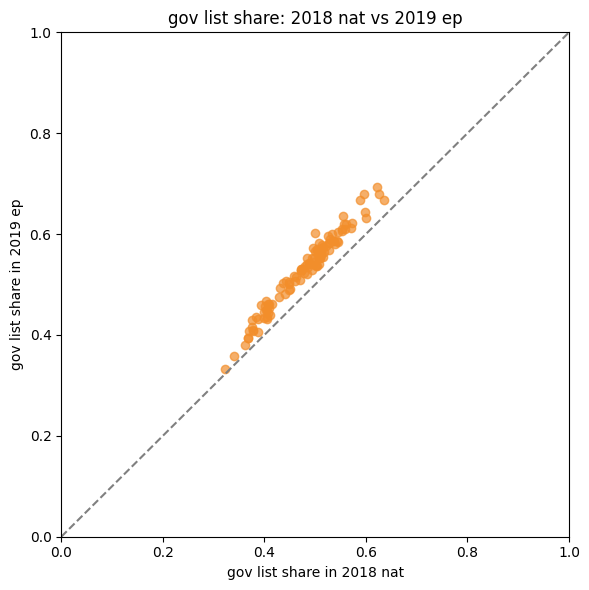


correlation matrix:
party_block              gov_list_share_2018_nat  gov_list_share_2019_ep
party_block                                                             
gov_list_share_2018_nat                    1.000                   0.984
gov_list_share_2019_ep                     0.984                   1.000

matched oevk count (2022 nat vs 2024 ep): 106


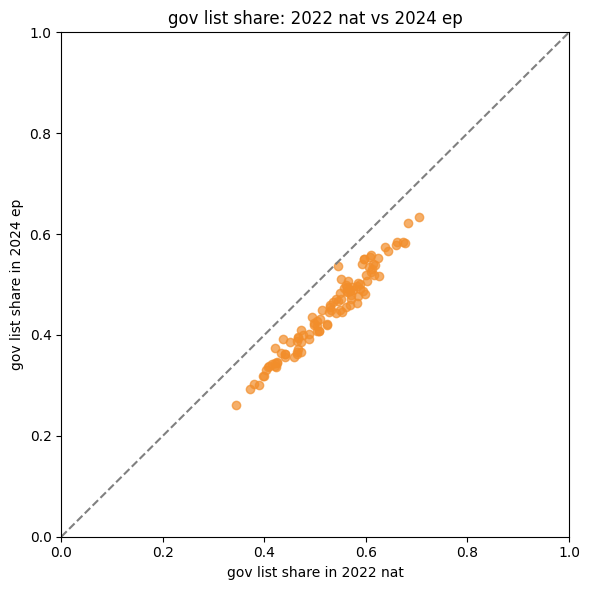


correlation matrix:
party_block              gov_list_share_2022_nat  gov_list_share_2024_ep
party_block                                                             
gov_list_share_2022_nat                    1.000                   0.976
gov_list_share_2024_ep                     0.976                   1.000


In [7]:
# this block checks correlations so we can spot variables that overlap too much.
import matplotlib.pyplot as plt

def match_two_elections(panel, year1, etype1, year2, etype2, col="gov_list_share"):
    """match the same oevk between two elections and plot scatter"""
    df1 = panel[
        (panel["year"] == year1)
        & (panel["election_type"] == etype1)
    ][["oevk_id", col]].rename(columns={col: f"{col}_{year1}_{etype1}"})

    df2 = panel[
        (panel["year"] == year2)
        & (panel["election_type"] == etype2)
    ][["oevk_id", col]].rename(columns={col: f"{col}_{year2}_{etype2}"})

    merged = df1.merge(df2, on="oevk_id", how="inner")
    print(f"\nmatched oevk count ({year1} {etype1} vs {year2} {etype2}): {len(merged)}")

    if merged.empty:
        print("no common oevk_id between these two elections")
        return None

    xcol = f"{col}_{year1}_{etype1}"
    ycol = f"{col}_{year2}_{etype2}"

    color_map = {
        "gov_list_share": "#f28e2b",
        "opp_list_share": "#4e79a7",
        "opp_radical_list_share": "#59a14f",
        "other_list_share": "#9c9c9c",
    }

    plt.figure(figsize=(6, 6))
    plt.scatter(merged[xcol], merged[ycol], alpha=0.7, color=color_map.get(col, "#9c9c9c"))
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    plt.xlabel(f"{col.replace('_', ' ')} in {year1} {etype1}")
    plt.ylabel(f"{col.replace('_', ' ')} in {year2} {etype2}")
    plt.title(f"{col.replace('_', ' ')}: {year1} {etype1} vs {year2} {etype2}")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    print("\ncorrelation matrix:")
    print(merged[[xcol, ycol]].corr().round(3))

    return merged

# 2018 nat vs 2019 ep
gov_18_nat_19_ep = match_two_elections(
    oevk_block_panel,
    year1=2018, etype1="nat",
    year2=2019, etype2="ep",
    col="gov_list_share"
)

# 2022 nat vs 2024 ep
gov_22_nat_24_ep = match_two_elections(
    oevk_block_panel,
    year1=2022, etype1="nat",
    year2=2024, etype2="ep",
    col="gov_list_share"
)

# optional clean-up
for var in ["match_two_elections"]:
    if var in locals():
        del locals()[var]
del var

Interpretation. Very high correlations suggest the variables carry overlapping information.


### Additional exploratory visuals

These figures summarize the national block balance, local competitiveness, and poll availability before each election.

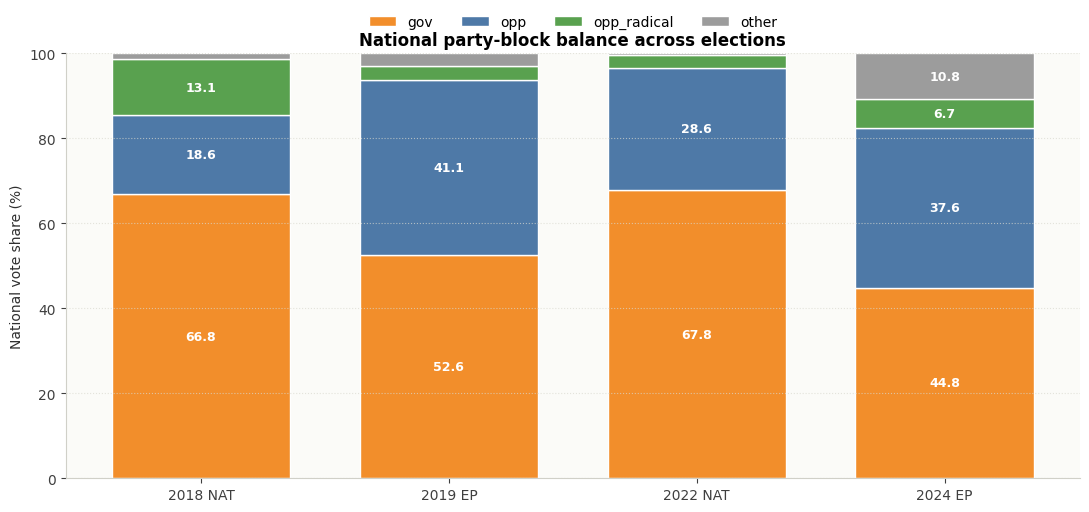

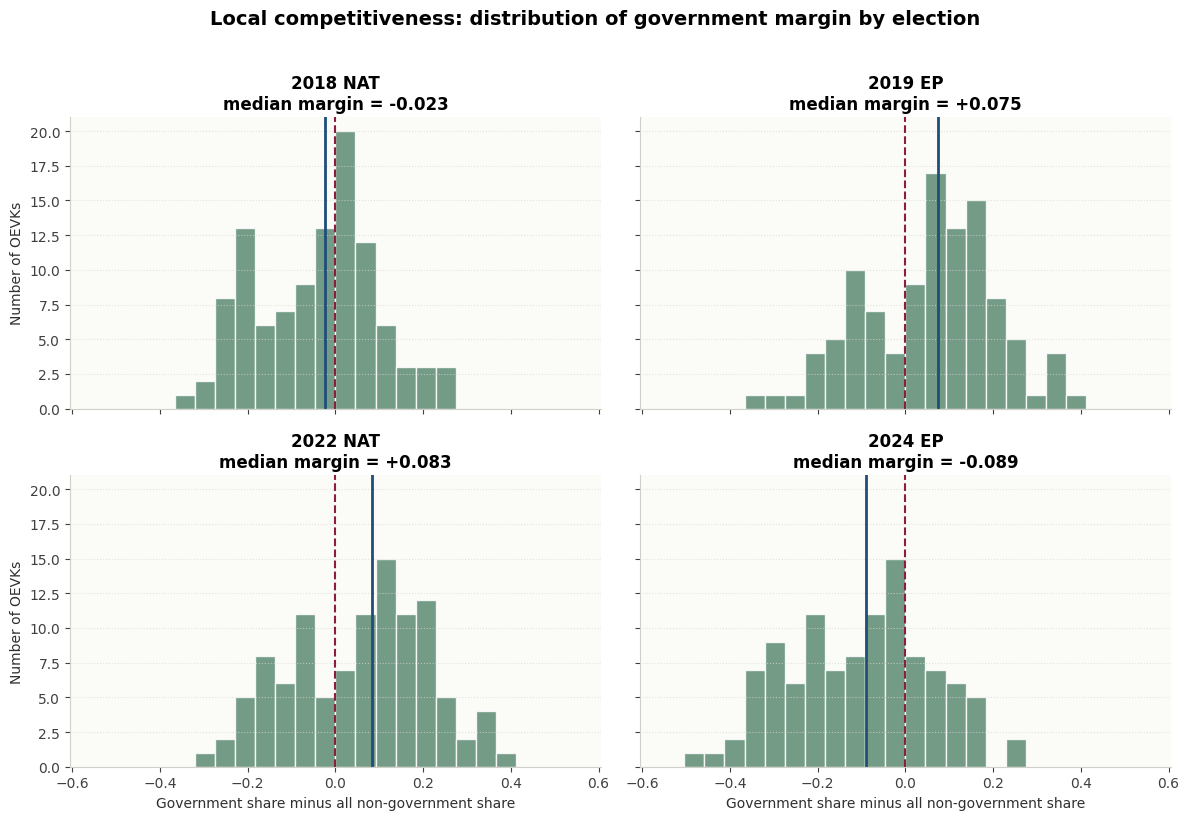

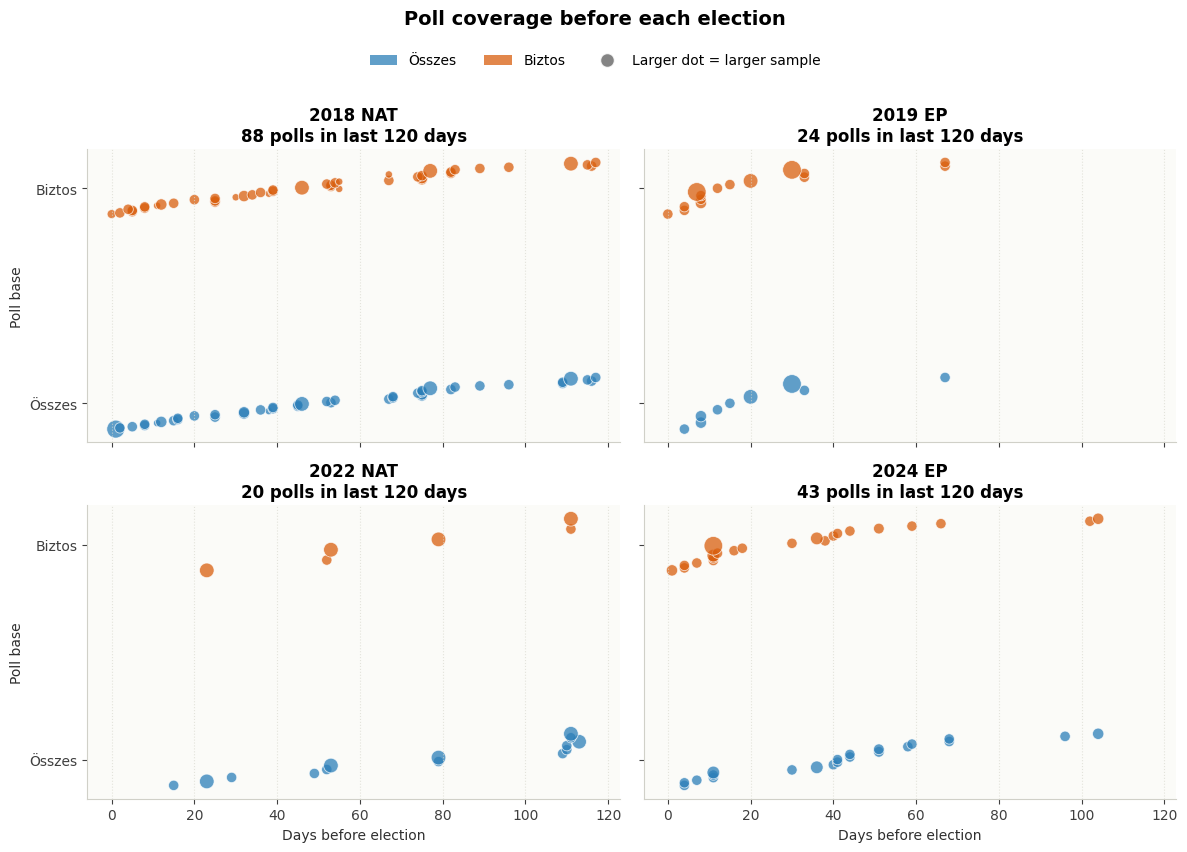

In [8]:
# this block adds extra figures to show how district patterns change across elections.
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fbfbf8",
    "axes.edgecolor": "#d0d0c8",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#2f2f2f",
    "xtick.color": "#3f3f3f",
    "ytick.color": "#3f3f3f",
    "grid.color": "#d9d9cf",
    "grid.linestyle": ":",
    "grid.alpha": 0.7,
})

block_palette = {
    "gov": "#f28e2b",
    "opp": "#4e79a7",
    "opp_radical": "#59a14f",
    "other": "#9c9c9c",
}
basis_palette = {
    "Összes": "#2c7fb8",
    "Biztos": "#d95f0e",
}

if "mandates_all_combined" not in locals() or "final_results_oevk_party" not in locals() or "polls" not in locals():
    try:
        here = Path(__file__).resolve().parent
    except NameError:
        here = Path.cwd()

    project_root = here
    while not (project_root / "data").exists() and project_root != project_root.parent:
        project_root = project_root.parent
    created_dir = project_root / "data" / "created"

    mandates_all_combined = pd.read_csv(created_dir / "global_results.csv")
    final_results_oevk_party = pd.read_csv(created_dir / "oevk_results.csv")
    polls = pd.read_csv(created_dir / "polls.csv")

# 1) national block balance across elections
national_blocks = mandates_all_combined.copy()
national_blocks["percent"] = pd.to_numeric(national_blocks["percent"], errors="coerce")
national_blocks = national_blocks.dropna(subset=["year", "election_type", "party_block", "percent"]).copy()
national_blocks["label"] = (
    national_blocks["year"].astype(int).astype(str)
    + " "
    + national_blocks["election_type"].astype(str).str.upper()
)

block_order = ["gov", "opp", "opp_radical", "other"]

national_summary = (
    national_blocks
    .groupby(["year", "election_type", "label", "party_block"], as_index=False)["percent"]
    .sum()
)

wide_blocks = (
    national_summary
    .pivot(index=["year", "election_type", "label"], columns="party_block", values="percent")
    .reindex(columns=block_order)
    .fillna(0)
    .reset_index()
    .sort_values(["year", "election_type"])
)

fig, ax = plt.subplots(figsize=(11, 5.2))
x = np.arange(len(wide_blocks))
bottom = np.zeros(len(wide_blocks))

for block in block_order:
    values = wide_blocks[block].to_numpy(dtype="float64")
    ax.bar(
        x,
        values,
        bottom=bottom,
        color=block_palette[block],
        width=0.72,
        edgecolor="white",
        linewidth=1.0,
        label=block,
    )

    for xi, yi, bi in zip(x, values, bottom):
        if yi >= 6:
            ax.text(
                xi,
                bi + yi / 2,
                f"{yi:.1f}",
                ha="center",
                va="center",
                color="white",
                fontsize=9,
                fontweight="bold",
            )

    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(wide_blocks["label"])
ax.set_ylim(0, 100)
ax.set_ylabel("National vote share (%)")
ax.set_title("National party-block balance across elections")
ax.grid(axis="y")
ax.legend(ncols=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.show()

# 2) local competitiveness: government minus non-government margin in each OEVK
block_df = final_results_oevk_party.copy()
for col in ["list_votes", "valid_list_total"]:
    block_df[col] = pd.to_numeric(block_df[col], errors="coerce")

block_df = block_df.dropna(
    subset=["year", "election_type", "oevk_id", "party_block", "list_votes", "valid_list_total"]
).copy()

block_votes = (
    block_df
    .groupby(["year", "election_type", "oevk_id", "party_block"], as_index=False)
    .agg(
        list_votes=("list_votes", "sum"),
        valid_list_total=("valid_list_total", "first"),
    )
)
block_votes["share"] = block_votes["list_votes"] / block_votes["valid_list_total"].replace({0: np.nan})

margin_panel = (
    block_votes
    .pivot(index=["year", "election_type", "oevk_id"], columns="party_block", values="share")
    .reset_index()
)

for col in block_order:
    if col not in margin_panel.columns:
        margin_panel[col] = np.nan

margin_panel["gov_margin"] = margin_panel["gov"].fillna(0) - margin_panel[["opp", "opp_radical", "other"]].fillna(0).sum(axis=1)
margin_panel["label"] = (
    margin_panel["year"].astype(int).astype(str)
    + " "
    + margin_panel["election_type"].astype(str).str.upper()
)

margin_order = (
    margin_panel[["year", "election_type", "label"]]
    .drop_duplicates()
    .sort_values(["year", "election_type"])["label"]
    .tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
bins = np.linspace(-0.55, 0.55, 25)

for ax, label in zip(axes, margin_order):
    sub = margin_panel.loc[margin_panel["label"] == label, "gov_margin"].dropna()
    ax.hist(sub, bins=bins, color="#5b8a72", alpha=0.85, edgecolor="white")
    ax.axvline(0, color="#8b1e3f", linestyle="--", linewidth=1.5)
    ax.axvline(sub.median(), color="#1f4e79", linewidth=2)
    ax.set_title(f"{label}\nmedian margin = {sub.median():+.3f}")
    ax.grid(axis="y")

for ax in axes[2:]:
    ax.set_xlabel("Government share minus all non-government share")
for ax in axes[::2]:
    ax.set_ylabel("Number of OEVKs")

fig.suptitle(
    "Local competitiveness: distribution of government margin by election",
    y=1.02,
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# 3) poll coverage in the last 120 days before each election
polls_viz_base = polls.copy()
polls_viz_base["end_date"] = pd.to_datetime(polls_viz_base["Vég"], errors="coerce")
polls_viz_base["sample_size"] = pd.to_numeric(polls_viz_base["Minta"], errors="coerce")
polls_viz_base["Adatok.bázisa"] = polls_viz_base["Adatok.bázisa"].astype("string").str.strip()
polls_viz_base["focus"] = polls_viz_base["Fókusz"].astype("string").str.strip().fillna("")
polls_viz_base = polls_viz_base[polls_viz_base["Adatok.bázisa"].isin(["Összes", "Biztos"])].copy()
polls_viz_base = polls_viz_base.dropna(subset=["end_date", "sample_size"]).copy()

elections = {
    "2018 NAT": {"date": pd.Timestamp("2018-04-08"), "focus": ""},
    "2019 EP": {"date": pd.Timestamp("2019-05-26"), "focus": "EP"},
    "2022 NAT": {"date": pd.Timestamp("2022-04-03"), "focus": ""},
    "2024 EP": {"date": pd.Timestamp("2024-06-09"), "focus": "EP"},
}

coverage_rows = []
for label, meta in elections.items():
    election_date = meta["date"]
    is_ep = (meta["focus"] == "EP")
    
    # Robust selection logic from notebooks 12/13:
    if is_ep:
        focus_mask = polls_viz_base["focus"].eq("EP")
    else:
        focus_mask = polls_viz_base["focus"].eq("")

    sub = polls_viz_base[
        (polls_viz_base["end_date"] <= election_date)
        & (polls_viz_base["end_date"] >= election_date - pd.Timedelta(days=120))
        & focus_mask
    ].copy()

    if sub.empty:
        continue

    sub["days_before"] = (election_date - sub["end_date"]).dt.days
    sub["election"] = label
    coverage_rows.append(sub[["election", "Adatok.bázisa", "Adatgazda", "days_before", "sample_size"]])

coverage = (
    pd.concat(coverage_rows, ignore_index=True)
    if coverage_rows
    else pd.DataFrame(columns=["election", "Adatok.bázisa", "Adatgazda", "days_before", "sample_size"])
)

if coverage.empty:
    print("No polls available in the selected pre-election windows.")
else:
    coverage["point_size"] = np.clip(coverage["sample_size"].fillna(0) / 18, 24, 180)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, label in zip(axes, elections.keys()):
        sub = coverage[coverage["election"] == label].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        for basis in ["Összes", "Biztos"]:
            basis_sub = sub[sub["Adatok.bázisa"] == basis].copy()
            if basis_sub.empty:
                continue

            base_y = 0 if basis == "Összes" else 1
            offsets = np.linspace(-0.12, 0.12, max(len(basis_sub), 2))[: len(basis_sub)]
            ax.scatter(
                basis_sub["days_before"],
                np.full(len(basis_sub), base_y) + offsets,
                s=basis_sub["point_size"],
                color=basis_palette[basis],
                alpha=0.75,
                edgecolors="white",
                linewidths=0.6,
            )

        ax.set_title(f"{label}\n{len(sub)} polls in last 120 days")
        ax.set_yticks([0, 1])
        ax.set_yticklabels(["Összes", "Biztos"])
        ax.invert_xaxis()
        ax.grid(axis="x")

    for ax in axes[2:]:
        ax.set_xlabel("Days before election")
    for ax in axes[::2]:
        ax.set_ylabel("Poll base")

    legend_items = [
        Patch(facecolor=basis_palette["Összes"], label="Összes", alpha=0.75),
        Patch(facecolor=basis_palette["Biztos"], label="Biztos", alpha=0.75),
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Larger dot = larger sample",
            markerfacecolor="#666666",
            markersize=10,
            alpha=0.8,
        ),
    ]

    fig.legend(
        handles=legend_items,
        frameon=False,
        loc="upper center",
        ncols=3,
        bbox_to_anchor=(0.5, 1.02),
    )
    fig.suptitle("Poll coverage before each election", y=1.06, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# clean up helper variables
for var in [
    "ax",
    "axes",
    "basis",
    "basis_sub",
    "bins",
    "block",
    "block_df",
    "block_order",
    "block_palette",
    "block_votes",
    "bottom",
    "col",
    "coverage",
    "coverage_rows",
    "created_dir",
    "election_date",
    "elections",
    "fig",
    "here",
    "label",
    "legend_items",
    "margin_order",
    "margin_panel",
    "national_blocks",
    "national_summary",
    "offsets",
    "polls_viz",
    "sub",
    "values",
    "wide_blocks",
    "x",
    "xi",
    "yi",
    "bi",
    "base_y",
]:
    if var in locals():
        del locals()[var]

del var

# little problem
#"The percent column in global_results.csv uses two different metrics. For the
#  2018 and 2022 national elections, it shows seat shares. For the 2019 and 2024
#  EP elections, it shows vote shares. These metrics are not comparable on one
#  axis. Seat shares are much higher than vote shares in Hungary. This makes the
#  government look stronger than it was in the voting booths. To fix this,
#  calculate the true national vote shares for 2018 and 2022 from the
  #oevk_results.csv table."

### Easy English interpretation of the last two figures

**1. Local competitiveness: distribution of government margin by election**

This figure shows how strong the government side was in each OEVK compared to all non-government blocks together.

- If a value is above `0`, the government was stronger in that district.
- If a value is below `0`, the non-government side was stronger there.
- If many districts are close to `0`, the election was more competitive in local terms.

The median line helps us see the typical district.

- If the median is clearly above `0`, then the government had an overall local advantage.
- If the histogram is wide, districts were very different from each other.
- If the histogram is narrow, districts were more similar.

So this figure is useful because it does not only say who was stronger nationally. It shows whether that strength was spread across many districts or only concentrated in some places.

Red line = zero, blue line = median.

**2. Poll coverage before each election**

This figure shows how many polls were available before each election, how close they were to election day, and whether they were `Összes` or `Biztos` polls.

- More dots mean more poll information.
- Bigger dots mean bigger sample size.
- Dots closer to the left side mean they were closer to election day, because the x-axis is inverted.

This helps us understand how strong the poll-based analysis can be.

- If one election has many big dots close to election day, then we had a stronger poll basis there.
- If one election has only a few dots, or mostly older dots, then poll-based conclusions are less secure.

So the main message of this figure is simple: not all elections are equally well covered by polls, and this matters when we later build models or interpret poll results.

### Pollster activity summary

This block summarizes pollster activity in the polling database.

Rules used here:

- count unique poll fieldwork windows rather than raw rows
- treat `Összes` and `Biztos` rows from the same fieldwork period as one poll
- show the latest poll year available for each pollster
- report the average sample size across those unique polls


In [9]:
# this block saves the result so it can be reused later in the project.
pollster_activity_source = polls.copy()
pollster_activity_source["pollster"] = pollster_activity_source["Adatgazda"].astype("string").str.strip()
pollster_activity_source["pollster"] = pollster_activity_source["pollster"].replace({"": pd.NA, "nan": pd.NA, "<NA>": pd.NA})
pollster_activity_source["sample_size"] = pd.to_numeric(pollster_activity_source["Minta"], errors="coerce")

pollster_activity_source["poll_end_date"] = pd.to_datetime(
    pollster_activity_source["Vég"],
    errors="coerce",
)
unix_end_fallback = pd.to_datetime(
    pd.to_numeric(pollster_activity_source["UnixEnd"], errors="coerce"),
    unit="s",
    errors="coerce",
)
pollster_activity_source["poll_end_date"] = pollster_activity_source["poll_end_date"].fillna(unix_end_fallback)
pollster_activity_source["latest_poll_year"] = pollster_activity_source["poll_end_date"].dt.year

poll_identity_cols = [
    "pollster",
    "Kezdet",
    "Vég",
    "Mód",
    "Minta",
    "Megrendelő",
    "UnixStart",
    "UnixEnd",
]

unique_poll_activity = (
    pollster_activity_source
    .dropna(subset=["pollster"])
    .drop_duplicates(subset=poll_identity_cols)
    .copy()
)

pollster_activity_summary = (
    unique_poll_activity
    .groupby("pollster", as_index=False)
    .agg(
        unique_polls=("pollster", "size"),
        latest_poll_year=("latest_poll_year", "max"),
        average_sample_size=("sample_size", "mean"),
    )
    .rename(
        columns={
            "pollster": "Pollster",
            "unique_polls": "Unique polls",
            "latest_poll_year": "Latest poll year",
            "average_sample_size": "Average sample size",
        }
    )
    .sort_values(["Unique polls", "Latest poll year", "Pollster"], ascending=[False, False, True])
    .reset_index(drop=True)
)

pollster_activity_summary["Unique polls"] = pollster_activity_summary["Unique polls"].astype(int)
pollster_activity_summary["Average sample size"] = pollster_activity_summary["Average sample size"].round(1)
pollster_activity_summary["Latest poll year"] = pollster_activity_summary["Latest poll year"].astype("Int64")

display(pollster_activity_summary)

try:
    here = Path(__file__).resolve().parent
except NameError:
    here = Path.cwd()

project_root = here
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

pollster_activity_csv_path = project_root / "data" / "created" / "pollster_activity_summary.csv"
pollster_activity_output_paths = [
    project_root / "graphs_tables" / "pollster_activity_summary.tex",
    project_root / "doc" / "ÚJLaTex_ENGLISH_Template másolat 2" / "figures" / "pollster_activity_summary.tex",
]

pollster_activity_csv_path.parent.mkdir(parents=True, exist_ok=True)
for output_path in pollster_activity_output_paths:
    output_path.parent.mkdir(parents=True, exist_ok=True)

pollster_activity_summary.to_csv(pollster_activity_csv_path, index=False)

pollster_activity_latex = pollster_activity_summary.copy()
pollster_activity_latex["Unique polls"] = pollster_activity_latex["Unique polls"].map(lambda value: f"{int(value)}")
pollster_activity_latex["Latest poll year"] = pollster_activity_latex["Latest poll year"].map(
    lambda value: "" if pd.isna(value) else f"{int(value)}"
)
pollster_activity_latex["Average sample size"] = pollster_activity_latex["Average sample size"].map(
    lambda value: "" if pd.isna(value) else f"{value:.1f}"
)

pollster_activity_latex_string = pollster_activity_latex.to_latex(
    index=False,
    escape=False,
    caption="Pollster activity summary in the Vox Populi polling database",
    label="tab:pollster_activity_summary",
    column_format="lrrr",
)
for output_path in pollster_activity_output_paths:
    output_path.write_text(pollster_activity_latex_string, encoding="utf-8")

print("Saved pollster activity CSV to:")
print(pollster_activity_csv_path)
print()
print("Saved pollster activity LaTeX table to:")
for output_path in pollster_activity_output_paths:
    print(output_path)

for var in [
    "here",
    "poll_identity_cols",
    "pollster_activity_csv_path",
    "pollster_activity_latex",
    "pollster_activity_latex_string",
    "pollster_activity_output_paths",
    "pollster_activity_source",
    "unique_poll_activity",
    "unix_end_fallback",
    "output_path",
]:
    if var in locals():
        del locals()[var]
del var


,Pollster,Unique polls,Latest poll year,Average sample size
0,Nézőpont,145,2026,1340.3
1,Publicus,135,2026,1033.3
2,ZRI,100,2026,1031.2
3,IDEA,90,2026,1737.9
4,Medián,78,2026,1131.5
5,Republikon,69,2026,1026.1
6,21 Kutató,56,2026,924.1
7,névtelen,35,2020,500.0
8,Századvég,34,2026,2729.4
9,Iránytű,28,2026,2221.8


Saved pollster activity CSV to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/data/created/pollster_activity_summary.csv

Saved pollster activity LaTeX table to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/graphs_tables/pollster_activity_summary.tex


Interpretation. More polls mean better historical coverage for that pollster, not automatically better quality.


Define election dates for 365-day filtering.


In [10]:
# define election dates for 365-day filtering
election_meta_summary = {
    "2018_nat": pd.Timestamp("2018-04-08"),
    "2019_ep": pd.Timestamp("2019-05-26"),
    "2022_nat": pd.Timestamp("2022-04-03"),
    "2024_ep": pd.Timestamp("2024-06-09"),
    "2026_nat": pd.Timestamp("2026-04-12"),
}

# 1) Start from the raw polls dataframe
pollster_activity_filtered_source = polls.copy()

# keep only rows where Fókusz is either missing or EP (since I want to keep only polls that are either non-focused or explicitly focused on EP elections)
pollster_activity_filtered_source["Fókusz"] = pollster_activity_filtered_source["Fókusz"].astype("string").str.strip()
pollster_activity_filtered_source = pollster_activity_filtered_source[
    pollster_activity_filtered_source["Fókusz"].isna()
    | (pollster_activity_filtered_source["Fókusz"] == "EP")
].copy()

# 2) Standardize pollster name and sample size
pollster_activity_filtered_source["pollster"] = pollster_activity_filtered_source["Adatgazda"].astype("string").str.strip()
pollster_activity_filtered_source["sample_size"] = pd.to_numeric(pollster_activity_filtered_source["Minta"], errors="coerce")
pollster_activity_filtered_source["poll_end_date"] = pd.to_datetime(pollster_activity_filtered_source["Vég"], errors="coerce")

# 3) Define filtering logic: keep only polls within 365 days of an election day
filtered_rows = []
for election, election_date in election_meta_summary.items():
    # same logic as in notebook 09
    if "ep" in election:
        focus_mask = pollster_activity_filtered_source["Fókusz"].fillna("").eq("EP")
    else:
        focus_mask = pollster_activity_filtered_source["Fókusz"].fillna("").eq("")

    mask = (
        focus_mask
        & pollster_activity_filtered_source["poll_end_date"].notna()
        & (pollster_activity_filtered_source["poll_end_date"] <= election_date)
        & (pollster_activity_filtered_source["poll_end_date"] >= election_date - pd.Timedelta(days=365))
        & pollster_activity_filtered_source["sample_size"].notna()
        & (pollster_activity_filtered_source["sample_size"] > 0)
    )
    filtered_rows.append(pollster_activity_filtered_source.loc[mask])

unique_poll_activity_filtered = pd.concat(filtered_rows).drop_duplicates(subset=["Adatgazda", "UnixStart", "UnixEnd"]).copy()

# 4) Calculate summary statistics
pollster_activity_summary_filtered = (
    unique_poll_activity_filtered
    .groupby("pollster", as_index=False)
    .agg(
        unique_polls=("pollster", "size"),
        latest_poll_year=("poll_end_date", lambda x: x.dt.year.max()),
        average_sample_size=("sample_size", "mean"),
    )
    .rename(
        columns={
            "pollster": "Pollster",
            "unique_polls": "Unique polls",
            "latest_poll_year": "Latest poll year",
            "average_sample_size": "Average sample size",
        }
    )
    .sort_values(["Unique polls", "Latest poll year", "Pollster"], ascending=[False, False, True])
    .reset_index(drop=True)
)

pollster_activity_summary_filtered["Unique polls"] = pollster_activity_summary_filtered["Unique polls"].astype(int)
pollster_activity_summary_filtered["Average sample size"] = pollster_activity_summary_filtered["Average sample size"].round(1)
pollster_activity_summary_filtered["Latest poll year"] = pollster_activity_summary_filtered["Latest poll year"].astype("Int64")

display(pollster_activity_summary_filtered)

# 5) Export paths
try:
    here_tmp = Path(__file__).resolve().parent
except NameError:
    here_tmp = Path.cwd()

project_root_tmp = here_tmp
while not (project_root_tmp / "data").exists() and project_root_tmp != project_root_tmp.parent:
    project_root_tmp = project_root_tmp.parent

pollster_activity_filtered_csv_path = project_root_tmp / "data" / "created" / "pollster_activity_summary_filtered.csv"
pollster_activity_filtered_output_paths = [
    project_root_tmp / "graphs_tables" / "pollster_activity_summary_filtered.tex",
    project_root_tmp / "doc" / "ÚJLaTex_ENGLISH_Template másolat 2" / "figures" / "pollster_activity_summary_filtered.tex",
]

pollster_activity_summary_filtered.to_csv(pollster_activity_filtered_csv_path, index=False)
for output_path in pollster_activity_filtered_output_paths:
    output_path.parent.mkdir(parents=True, exist_ok=True)

# 6) Export LaTeX table
pollster_activity_filtered_latex = pollster_activity_summary_filtered.copy()
pollster_activity_filtered_latex["Unique polls"] = pollster_activity_filtered_latex["Unique polls"].map(lambda value: f"{int(value)}")
pollster_activity_filtered_latex["Latest poll year"] = pollster_activity_filtered_latex["Latest poll year"].map(
    lambda value: "" if pd.isna(value) else f"{int(value)}"
)
pollster_activity_filtered_latex["Average sample size"] = pollster_activity_filtered_latex["Average sample size"].map(
    lambda value: "" if pd.isna(value) else f"{value:.1f}"
)

pollster_activity_filtered_latex_string = pollster_activity_filtered_latex.to_latex(
    index=False,
    escape=False,
    caption="Pollster activity summary in the campaign-period polling database (filtered)",
    label="tab:pollster_activity_summary_filtered",
    column_format="lrrr",
)
for output_path in pollster_activity_filtered_output_paths:
    output_path.write_text(pollster_activity_filtered_latex_string, encoding="utf-8")

print("Saved filtered pollster activity CSV to:")
print(pollster_activity_filtered_csv_path)
print()
print("Saved filtered pollster activity LaTeX table to:")
for output_path in pollster_activity_filtered_output_paths:
    print(output_path)

for var in [
    "election_meta_summary",
    "pollster_activity_filtered_source",
    "filtered_rows",
    "unique_poll_activity_filtered",
    "pollster_activity_summary_filtered",
    "pollster_activity_filtered_csv_path",
    "pollster_activity_filtered_latex",
    "pollster_activity_filtered_latex_string",
    "pollster_activity_filtered_output_paths",
    "here_tmp",
    "project_root_tmp",
    "output_path",
]:
    if var in locals():
        del locals()[var]
del var


,Pollster,Unique polls,Latest poll year,Average sample size
0,Republikon,29,2026,1017.2
1,Publicus,28,2026,1003.4
2,ZRI,28,2026,1053.6
3,IDEA,27,2026,1666.7
4,Nézőpont,25,2026,1470.0
5,Medián,19,2026,1147.4
6,Iránytű,14,2026,1358.5
7,21 Kutató,11,2026,1163.6
8,e-benchmark,10,2022,1000.0
9,Századvég,9,2024,1000.0


Saved filtered pollster activity CSV to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/data/created/pollster_activity_summary_filtered.csv

Saved filtered pollster activity LaTeX table to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/graphs_tables/pollster_activity_summary_filtered.tex


### Missingness-based structure predictor choice for no-imputation models

This block asks a practical question:

Which structural predictors have enough data to use safely, and which ones have too much missing data?

Method:

- expand the numeric statistical pool into per-1,000-resident and share features where possible
- measure non-missing share by election year
- classify features with a strict `95%` minimum-coverage rule

Interpretation:

- `keep_full_history` = enough data in all historical years and in `2026`
- `drop_for_no_imputation` = too much data is missing

The tables below first show feature-level NA patterns, then a short NA summary before the smaller manual shortlist.


In [11]:
# this block checks missingness so we can see which predictors are safe to use later.
strict_coverage_threshold = 0.95
full_history_years = [2018, 2019, 2022, 2024]

def build_expanded_structure_features(source_df):
    df = source_df.copy()

    raw_numeric_inputs = [
        "pop_total",
        "pop_0_14",
        "pop_65_plus",
        "pop_perm",
        "pop_perm_0_14_female",
        "pop_perm_65_plus_female",
        "pop_perm_0_14_male",
        "pop_perm_65_plus_male",
        "pop_perm_0_24",
        "budget_revenue",
        "budget_expenditure",
        "dwellings_built",
        "dwellings_terminated",
        "dwellings_built_muni",
        "dwellings_built_private",
        "gps_doctors",
        "pediatric_doctors",
        "cars",
        "internet_other",
        "tv_subs",
        "cars_first_reg",
        "post_offices",
        "internet_total",
        "internet_xdsl",
        "internet_cable",
        "internet_optical",
        "unemployed_total",
        "unemployed_180_plus",
        "unemployed_univ",
        "unemployed_bluecollar",
        "unemployed_young",
        "unemployed_365_plus",
        "labour_income_million_huf_t_3",
        "labor_income_million_huf_t_3_real2010",
        "cpi",
    ]

    for col in raw_numeric_inputs:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    pop_total = pd.to_numeric(df["pop_total"], errors="coerce")
    pop_denom = pop_total.replace({0: np.nan})
    rate_scale = 1000.0

    feature_rows = []

    def add_feature(feature_name, values, source_col, transform):
        df[feature_name] = values
        feature_rows.append(
            {
                "feature": feature_name,
                "source_col": source_col,
                "transform": transform,
            }
        )

    add_feature("log_pop_total", np.log1p(pop_total), "pop_total", "log")

    share_features = {
        "pop_0_14": "young_share",
        "pop_65_plus": "old_share",
        "pop_perm": "perm_population_share",
        "pop_perm_0_14_female": "perm_0_14_female_share",
        "pop_perm_65_plus_female": "perm_65_plus_female_share",
        "pop_perm_0_14_male": "perm_0_14_male_share",
        "pop_perm_65_plus_male": "perm_65_plus_male_share",
        "pop_perm_0_24": "perm_0_24_share",
    }

    for source_col, feature_name in share_features.items():
        if source_col in df.columns:
            add_feature(feature_name, df[source_col] / pop_denom, source_col, "share_of_pop_total")

    per_1000_features = {
        "budget_revenue": "budget_revenue_per_capita",
        "budget_expenditure": "budget_expenditure_per_capita",
        "dwellings_built": "dwellings_per_capita",
        "dwellings_terminated": "dwellings_terminated_per_capita",
        "dwellings_built_muni": "dwellings_built_muni_per_capita",
        "dwellings_built_private": "dwellings_built_private_per_capita",
        "gps_doctors": "gps_doctors_per_capita",
        "pediatric_doctors": "pediatric_doctors_per_capita",
        "cars": "cars_per_capita",
        "internet_other": "internet_other_per_capita",
        "tv_subs": "tv_subs_per_capita",
        "cars_first_reg": "cars_first_reg_per_capita",
        "post_offices": "post_offices_per_capita",
        "internet_total": "internet_per_capita",
        "internet_xdsl": "internet_xdsl_per_capita",
        "internet_cable": "internet_cable_per_capita",
        "internet_optical": "internet_optical_per_capita",
        "unemployed_total": "unemployed_per_capita",
        "unemployed_180_plus": "unemployed_180_plus_per_capita",
        "unemployed_univ": "unemployed_univ_per_capita",
        "unemployed_bluecollar": "unemployed_bluecollar_per_capita",
        "unemployed_young": "unemployed_young_per_capita",
        "unemployed_365_plus": "unemployed_365_plus_per_capita",
        "labour_income_million_huf_t_3": "nominal_income_per_capita",
        "labor_income_million_huf_t_3_real2010": "real_income_per_capita",
    }

    for source_col, feature_name in per_1000_features.items():
        if source_col in df.columns:
            add_feature(feature_name, df[source_col] * rate_scale / pop_denom, source_col, "per_1000_residents")

    if {"gps_doctors", "pediatric_doctors"}.issubset(df.columns):
        add_feature(
            "doctor_per_capita",
            rate_scale * (df["gps_doctors"] + df["pediatric_doctors"]) / pop_denom,
            "gps_doctors+pediatric_doctors",
            "per_1000_residents_sum",
        )

    if {"budget_revenue", "budget_expenditure"}.issubset(df.columns):
        add_feature(
            "budget_balance_per_capita",
            rate_scale * (df["budget_revenue"] - df["budget_expenditure"]) / pop_denom,
            "budget_revenue-budget_expenditure",
            "per_1000_residents_difference",
        )

    if "cpi" in df.columns:
        add_feature("cpi", df["cpi"], "cpi", "raw")

    feature_metadata = pd.DataFrame(feature_rows)
    structure_feature_candidates = feature_metadata["feature"].tolist()
    return df, structure_feature_candidates, feature_metadata

predictor_source, structure_feature_candidates, structure_feature_metadata = build_expanded_structure_features(
    final_statistics_oevk
)

feature_rows = []
for feature in structure_feature_candidates:
    per_year_coverage = {}
    for year in full_history_years + [2026]:
        sub = predictor_source[predictor_source["year"] == year]
        per_year_coverage[year] = float(sub[feature].notna().mean()) if len(sub) else np.nan

    full_history_values = [
        per_year_coverage[year]
        for year in full_history_years
        if pd.notna(per_year_coverage[year])
    ]
    if min(full_history_values) >= strict_coverage_threshold and per_year_coverage[2026] >= strict_coverage_threshold:
        recommendation = "keep_full_history"
    else:
        recommendation = "drop_for_no_imputation"

    feature_rows.append(
        {
            "feature": feature,
            "nonmissing_2018": per_year_coverage[2018],
            "nonmissing_2019": per_year_coverage[2019],
            "nonmissing_2022": per_year_coverage[2022],
            "nonmissing_2024": per_year_coverage[2024],
            "nonmissing_2026": per_year_coverage[2026],
            "recommendation": recommendation,
        }
    )

feature_missingness = pd.DataFrame(feature_rows).sort_values(
    ["recommendation", "feature"],
    ascending=[True, True],
).reset_index(drop=True)

feature_missingness_display = feature_missingness[
    [
        "feature",
        "nonmissing_2018",
        "nonmissing_2019",
        "nonmissing_2022",
        "nonmissing_2024",
        "nonmissing_2026",
        "recommendation",
    ]
]

display(feature_missingness_display.round(3))

na_good_structure_features = [
    feature
    for feature in structure_feature_candidates
    if feature_missingness.set_index("feature").loc[feature, "recommendation"] == "keep_full_history"
]

na_summary = pd.DataFrame(
    [
        {
            "scenario": "all_structure_candidates",
            "feature_count": len(structure_feature_candidates),
            "note": "expanded non-media numeric feature pool before the NA based filter",
        },
        {
            "scenario": "na_good_structure_candidates",
            "feature_count": len(na_good_structure_features),
            "note": "structure features with at least 95% coverage in every historical year and in 2026",
        },
        {
            "scenario": "dropped_structure_candidates",
            "feature_count": int((feature_missingness["recommendation"] == "drop_for_no_imputation").sum()),
            "note": "structure features that fail the strict coverage rule",
        },
    ]
)

display(na_summary)

# clean up temporary variables, keep the reusable screening objects
for var in [
    "candidate_features",
    "feature",
    "feature_col",
    "feature_rows",
    "full_history_values",
    "media_missingness_outlets",
    "min_full_history",
    "min_recent",
    "na_good_structure_features",
    "na_summary",
    "outlet",
    "per_year_coverage",
    "raw_col",
    "recommendation",
    "recent_values",
    "structure_feature_metadata",
    "sub",
]:
    if var in locals():
        del locals()[var]
del var


,feature,nonmissing_2018,nonmissing_2019,nonmissing_2022,nonmissing_2024,nonmissing_2026,recommendation
0,cpi,0.849,0.849,0.849,0.849,0.849,drop_for_no_imputation
1,dwellings_built_muni_per_capita,0.255,0.217,0.321,0.321,0.264,drop_for_no_imputation
2,dwellings_terminated_per_capita,0.991,0.972,0.906,0.943,0.962,drop_for_no_imputation
3,internet_cable_per_capita,0.849,0.849,0.849,0.849,0.849,drop_for_no_imputation
4,internet_optical_per_capita,0.821,0.840,0.849,0.849,0.849,drop_for_no_imputation
5,internet_other_per_capita,0.849,0.849,0.849,0.849,0.849,drop_for_no_imputation
6,internet_per_capita,0.849,0.849,0.849,0.849,0.849,drop_for_no_imputation
7,internet_xdsl_per_capita,0.849,0.849,0.849,0.849,0.849,drop_for_no_imputation
8,nominal_income_per_capita,0.849,0.849,0.849,0.849,0.849,drop_for_no_imputation
9,real_income_per_capita,0.849,0.849,0.849,0.849,0.849,drop_for_no_imputation


,scenario,feature_count,note
0,all_structure_candidates,37,expanded non-media numeric feature pool before...
1,na_good_structure_candidates,26,structure features with at least 95% coverage ...
2,dropped_structure_candidates,11,structure features that fail the strict covera...


### Easy English interpretation of the missingness output

This output checks which structural predictors have enough data and which ones have too much missing data.

**Table 1: feature by feature missingness**

- `feature` = the predictor name
- `nonmissing_2018`, `nonmissing_2019`, `nonmissing_2022`, `nonmissing_2024`, `nonmissing_2026` = the share of districts with data in that year
- `recommendation` = the simple NA-based decision

Recommendation labels:

- `keep_full_history` = safe for a full history setup without imputation
- `drop_for_no_imputation` = too much data is missing

**Table 2: NA summary**

- `all_structure_candidates` = how many expanded structure variables were checked
- `na_good_structure_candidates` = how many passed the strict 95% coverage rule
- `dropped_structure_candidates` = how many failed that rule

Bottom line:

- this is only the NA-based first filter
- after this, I still make a shorter manual fundamentals shortlist so the exploratory section stays readable
- no model fitting happens below, only a cleaner pre-selection


In [12]:
# this block saves the result so it can be reused later in the project.
missingness_feature_labels = {
    "log_pop_total": "Log population",
    "young_share": "Age 0--14 share",
    "old_share": "Age 65+ share",
    "perm_population_share": "Permanent population share",
    "perm_0_14_female_share": "Permanent female age 0--14 share",
    "perm_65_plus_female_share": "Permanent female age 65+ share",
    "perm_0_14_male_share": "Permanent male age 0--14 share",
    "perm_65_plus_male_share": "Permanent male age 65+ share",
    "perm_0_24_share": "Permanent age 0--24 share",
    "budget_revenue_per_capita": "Budget revenue per 1,000 residents",
    "budget_expenditure_per_capita": "Budget expenditure per 1,000 residents",
    "dwellings_per_capita": "Dwellings built per 1,000 residents",
    "dwellings_terminated_per_capita": "Dwellings terminated per 1,000 residents",
    "dwellings_built_muni_per_capita": "Municipal dwellings built per 1,000 residents",
    "dwellings_built_private_per_capita": "Private dwellings built per 1,000 residents",
    "gps_doctors_per_capita": "General practitioners per 1,000 residents",
    "pediatric_doctors_per_capita": "Pediatric doctors per 1,000 residents",
    "cars_per_capita": "Cars per 1,000 residents",
    "internet_other_per_capita": "Other internet subscriptions per 1,000 residents",
    "tv_subs_per_capita": "TV subscriptions per 1,000 residents",
    "cars_first_reg_per_capita": "New car registrations per 1,000 residents",
    "post_offices_per_capita": "Post offices per 1,000 residents",
    "internet_per_capita": "Internet subscriptions per 1,000 residents",
    "internet_xdsl_per_capita": "xDSL internet subscriptions per 1,000 residents",
    "internet_cable_per_capita": "Cable internet subscriptions per 1,000 residents",
    "internet_optical_per_capita": "Optical internet subscriptions per 1,000 residents",
    "unemployed_per_capita": "Unemployed people per 1,000 residents",
    "unemployed_180_plus_per_capita": "Unemployed 180+ days per 1,000 residents",
    "unemployed_univ_per_capita": "University-educated unemployed per 1,000 residents",
    "unemployed_bluecollar_per_capita": "Blue-collar unemployed per 1,000 residents",
    "unemployed_young_per_capita": "Young unemployed per 1,000 residents",
    "unemployed_365_plus_per_capita": "Unemployed 365+ days per 1,000 residents",
    "nominal_income_per_capita": "Nominal labour income per 1,000 residents",
    "real_income_per_capita": "Real labour income per 1,000 residents",
    "doctor_per_capita": "Doctors per 1,000 residents",
    "budget_balance_per_capita": "Budget balance per 1,000 residents",
    "cpi": "Consumer price index",
}

feature_label_map = globals().get(
    "missingness_feature_labels",
    {
        "log_pop_total": "Log population",
        "young_share": "Age 0--14 share",
        "old_share": "Age 65+ share",
        "perm_population_share": "Permanent population share",
        "perm_0_14_female_share": "Permanent female age 0--14 share",
        "perm_65_plus_female_share": "Permanent female age 65+ share",
        "perm_0_14_male_share": "Permanent male age 0--14 share",
        "perm_65_plus_male_share": "Permanent male age 65+ share",
        "perm_0_24_share": "Permanent age 0--24 share",
        "budget_revenue_per_capita": "Budget revenue per 1,000 residents",
        "budget_expenditure_per_capita": "Budget expenditure per 1,000 residents",
        "dwellings_per_capita": "Dwellings built per 1,000 residents",
        "dwellings_terminated_per_capita": "Dwellings terminated per 1,000 residents",
        "dwellings_built_muni_per_capita": "Municipal dwellings built per 1,000 residents",
        "dwellings_built_private_per_capita": "Private dwellings built per 1,000 residents",
        "gps_doctors_per_capita": "General practitioners per 1,000 residents",
        "pediatric_doctors_per_capita": "Pediatric doctors per 1,000 residents",
        "cars_per_capita": "Cars per 1,000 residents",
        "internet_other_per_capita": "Other internet subscriptions per 1,000 residents",
        "tv_subs_per_capita": "TV subscriptions per 1,000 residents",
        "cars_first_reg_per_capita": "New car registrations per 1,000 residents",
        "post_offices_per_capita": "Post offices per 1,000 residents",
        "internet_per_capita": "Internet subscriptions per 1,000 residents",
        "internet_xdsl_per_capita": "xDSL internet subscriptions per 1,000 residents",
        "internet_cable_per_capita": "Cable internet subscriptions per 1,000 residents",
        "internet_optical_per_capita": "Optical internet subscriptions per 1,000 residents",
        "unemployed_per_capita": "Unemployed people per 1,000 residents",
        "unemployed_180_plus_per_capita": "Unemployed 180+ days per 1,000 residents",
        "unemployed_univ_per_capita": "University-educated unemployed per 1,000 residents",
        "unemployed_bluecollar_per_capita": "Blue-collar unemployed per 1,000 residents",
        "unemployed_young_per_capita": "Young unemployed per 1,000 residents",
        "unemployed_365_plus_per_capita": "Unemployed 365+ days per 1,000 residents",
        "nominal_income_per_capita": "Nominal labour income per 1,000 residents",
        "real_income_per_capita": "Real labour income per 1,000 residents",
        "doctor_per_capita": "Doctors per 1,000 residents",
        "budget_balance_per_capita": "Budget balance per 1,000 residents",
        "cpi": "Consumer price index",
    },
)

descriptive_stats_rows = []
summary_source = predictor_source[predictor_source["year"].isin(full_history_years + [2026])].copy()
for feature in feature_missingness["feature"]:
    series = pd.to_numeric(summary_source[feature], errors="coerce").dropna()
    descriptive_stats_rows.append(
        {
            "feature": feature,
            "Mean": float(series.mean()) if len(series) else np.nan,
            "Median": float(series.median()) if len(series) else np.nan,
            "SD": float(series.std()) if len(series) else np.nan,
            "Min": float(series.min()) if len(series) else np.nan,
            "Max": float(series.max()) if len(series) else np.nan,
        }
    )

descriptive_stats = pd.DataFrame(descriptive_stats_rows)

missingness_latex_table = (
    feature_missingness
    .drop(columns=["recommendation"])
    .merge(descriptive_stats, on="feature", how="left")
    .assign(
        feature=lambda df: df["feature"].map(
            lambda value: feature_label_map.get(
                value,
                value.replace("_", " ").title(),
            )
        )
    )
    .rename(
        columns={
            "feature": "Feature",
            "nonmissing_2018": "2018 NA",
            "nonmissing_2019": "2019 NA",
            "nonmissing_2022": "2022 NA",
            "nonmissing_2024": "2024 NA",
            "nonmissing_2026": "2026 NA",
        }
    )
    .sort_values("Feature")
)

missingness_latex_display = missingness_latex_table.copy()
for col in ["2018 NA", "2019 NA", "2022 NA", "2024 NA", "2026 NA"]:
    missingness_latex_display[col] = missingness_latex_display[col].map(
        lambda value: f"{100 * value:.1f}\%"
    )
for col in ["Mean", "Median", "SD", "Min", "Max"]:
    missingness_latex_display[col] = missingness_latex_display[col].map(
        lambda value: "" if pd.isna(value) else f"{value:.3f}"
    )

missingness_latex_string = missingness_latex_display.to_latex(
    index=False,
    escape=False,
    caption="Non-missing share and pooled descriptive statistics of candidate structural predictors",
    label="tab:structure_predictor_missingness",
    column_format="lcccccccccc",
)
missingness_latex_string = missingness_latex_string.replace(
    "\\begin{tabular}{lcccccccccc}",
    "\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}{lcccccccccc}",
)
missingness_latex_string = missingness_latex_string.replace(
    "\\end{tabular}",
    "\\end{tabular}%\n}",
)

if "project_root" not in locals():
    try:
        here = Path(__file__).resolve().parent
    except NameError:
        here = Path.cwd()

    project_root = here
    while not (project_root / "data").exists() and project_root != project_root.parent:
        project_root = project_root.parent

missingness_output_paths = [
    project_root / "graphs_tables" / "structure_predictor_missingness_table.tex",
    project_root / "doc" / "ÚJLaTex_ENGLISH_Template másolat 2" / "figures" / "structure_predictor_missingness_table.tex",
]
for output_path in missingness_output_paths:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(missingness_latex_string, encoding="utf-8")

display(missingness_latex_display)
print(missingness_latex_string)
print("Saved LaTeX table to:")
for output_path in missingness_output_paths:
    print(output_path)

for var in [
    "col",
    "descriptive_stats",
    "descriptive_stats_rows",
    "missingness_feature_labels",
    "missingness_latex_display",
    "missingness_latex_string",
    "missingness_latex_table",
    "missingness_output_paths",
    "series",
    "summary_source",
    "output_path",
]:
    if var in locals():
        del locals()[var]
del var


,Feature,2018 NA,2019 NA,2022 NA,2024 NA,2026 NA,Mean,Median,SD,Min,Max
36,Age 0--14 share,100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,0.145,0.143,0.016,0.089,0.188
21,Age 65+ share,100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,0.199,0.198,0.023,0.143,0.258
32,"Blue-collar unemployed per 1,000 residents",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,22.386,18.020,16.410,2.071,85.665
11,"Budget balance per 1,000 residents",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,5063.587,2933.861,65991.261,-413058.207,534617.354
12,"Budget expenditure per 1,000 residents",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,344918.361,301933.261,249629.591,112447.340,3220655.113
13,"Budget revenue per 1,000 residents",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,349981.948,316767.860,249034.477,115077.753,3755272.467
3,"Cable internet subscriptions per 1,000 residents",84.9\%,84.9\%,84.9\%,84.9\%,84.9\%,130.517,132.287,49.102,12.828,301.992
15,"Cars per 1,000 residents",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,395.535,394.152,64.516,224.710,676.379
0,Consumer price index,84.9\%,84.9\%,84.9\%,84.9\%,84.9\%,130.861,121.642,24.476,111.384,177.341
16,"Doctors per 1,000 residents",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,0.609,0.605,0.086,0.387,0.851


\begin{table}
\caption{Non-missing share and pooled descriptive statistics of candidate structural predictors}
\label{tab:structure_predictor_missingness}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccccc}
\toprule
Feature & 2018 NA & 2019 NA & 2022 NA & 2024 NA & 2026 NA & Mean & Median & SD & Min & Max \\
\midrule
Age 0--14 share & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 0.145 & 0.143 & 0.016 & 0.089 & 0.188 \\
Age 65+ share & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 0.199 & 0.198 & 0.023 & 0.143 & 0.258 \\
Blue-collar unemployed per 1,000 residents & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 22.386 & 18.020 & 16.410 & 2.071 & 85.665 \\
Budget balance per 1,000 residents & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 5063.587 & 2933.861 & 65991.261 & -413058.207 & 534617.354 \\
Budget expenditure per 1,000 residents & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 344918.361 & 301933.261 & 249629.591 & 112447.340 & 3220655.113 \\
Budget revenu

Interpretation. Lower coverage means the variable is harder to use safely without imputation.


### Preliminary NA-based fundamentals shortlist

To keep the exploratory notebook focused, I do a manual shortlist **after** the NA filter.

I keep variables that are:

- substantively easy to interpret
- available with very good coverage
- not just a more complicated duplicate of another variable already on the list

I do **not** fit models here yet.
This is still only a pre-selection step.

In [13]:
# this block builds or checks a smaller shortlist of variables for later modelling.
coverage_lookup = feature_missingness.set_index("feature")

preliminary_structure_shortlist_rows = [
    {
        "feature": "log_pop_total",
        "model_block": "demography",
        "why_keep": "clean district-size control with full coverage",
    },
    {
        "feature": "young_share",
        "model_block": "demography",
        "why_keep": "direct age-structure proxy with full coverage",
    },
    {
        "feature": "old_share",
        "model_block": "demography",
        "why_keep": "complements young_share and stays fully available",
    },
    {
        "feature": "unemployed_per_capita",
        "model_block": "core_economy",
        "why_keep": "simple labor-market stress proxy with full coverage",
    },
    {
        "feature": "unemployed_bluecollar_per_capita",
        "model_block": "core_economy",
        "why_keep": "adds a manual-labor unemployment slice with full coverage",
    },
    {
        "feature": "unemployed_univ_per_capita",
        "model_block": "core_economy",
        "why_keep": "adds a higher-education unemployment slice with full coverage",
    },
    {
        "feature": "budget_balance_per_capita",
        "model_block": "core_economy",
        "why_keep": "single fiscal balance proxy instead of keeping revenue and expenditure separately",
    },
    {
        "feature": "cars_per_capita",
        "model_block": "modernization",
        "why_keep": "clean mobility and modernization proxy with full coverage",
    },
    {
        "feature": "cars_first_reg_per_capita",
        "model_block": "modernization",
        "why_keep": "newer mobility proxy that complements the existing car-stock measure",
    },
    {
        "feature": "doctor_per_capita",
        "model_block": "public_service_housing",
        "why_keep": "simple access-to-services proxy with full coverage",
    },
    {
        "feature": "gps_doctors_per_capita",
        "model_block": "public_service_housing",
        "why_keep": "keeps the general-practitioner component separately with full coverage",
    },
    {
        "feature": "post_offices_per_capita",
        "model_block": "public_service_housing",
        "why_keep": "second service-access proxy with full coverage",
    },
    {
        "feature": "dwellings_built_private_per_capita",
        "model_block": "public_service_housing",
        "why_keep": "private housing-activity proxy with only one missing district in 2024 and 2026",
    },
]

preliminary_structure_shortlist = [row["feature"] for row in preliminary_structure_shortlist_rows]

for row in preliminary_structure_shortlist_rows:
    row["min_nonmissing_share"] = float(
        coverage_lookup.loc[
            row["feature"],
            ["nonmissing_2018", "nonmissing_2019", "nonmissing_2022", "nonmissing_2024", "nonmissing_2026"],
        ].min()
    )
    row["coverage_note"] = (
        "105/106 in 2024 and 2026"
        if row["feature"] == "dwellings_built_private_per_capita"
        else "106/106 in every year"
    )

preliminary_structure_shortlist_table = pd.DataFrame(preliminary_structure_shortlist_rows)

display(preliminary_structure_shortlist_table.round(3))

print("Preliminary NA-based structure shortlist:")
print(preliminary_structure_shortlist)

# clean up temporary variables, keep only the shortlist objects
for var in [
    "coverage_lookup",
    "preliminary_structure_shortlist_rows",
    "preliminary_structure_shortlist_table",
    "row",
]:
    if var in locals():
        del locals()[var]
del var


,feature,model_block,why_keep,min_nonmissing_share,coverage_note
0,log_pop_total,demography,clean district-size control with full coverage,1.000,106/106 in every year
1,young_share,demography,direct age-structure proxy with full coverage,1.000,106/106 in every year
2,old_share,demography,complements young_share and stays fully available,1.000,106/106 in every year
3,unemployed_per_capita,core_economy,simple labor-market stress proxy with full cov...,1.000,106/106 in every year
4,unemployed_bluecollar_per_capita,core_economy,adds a manual-labor unemployment slice with fu...,1.000,106/106 in every year
5,unemployed_univ_per_capita,core_economy,adds a higher-education unemployment slice wit...,1.000,106/106 in every year
6,budget_balance_per_capita,core_economy,single fiscal balance proxy instead of keeping...,1.000,106/106 in every year
7,cars_per_capita,modernization,clean mobility and modernization proxy with fu...,1.000,106/106 in every year
8,cars_first_reg_per_capita,modernization,newer mobility proxy that complements the exis...,1.000,106/106 in every year
9,doctor_per_capita,public_service_housing,simple access-to-services proxy with full cove...,1.000,106/106 in every year


Preliminary NA-based structure shortlist:
['log_pop_total', 'young_share', 'old_share', 'unemployed_per_capita', 'unemployed_bluecollar_per_capita', 'unemployed_univ_per_capita', 'budget_balance_per_capita', 'cars_per_capita', 'cars_first_reg_per_capita', 'doctor_per_capita', 'gps_doctors_per_capita', 'post_offices_per_capita', 'dwellings_built_private_per_capita']


Interpretation. Lower coverage means the variable is harder to use safely without imputation.


### Correlation table for the remaining fundamentals shortlist

After the NA-based keep/drop decision, the next exploratory question is simple:

- which of the remaining variables move very similarly
- and which ones still bring somewhat different information

This is still only predictor-vs-predictor comparison.
There is no target variable and no model fitting in this block.

,log_pop_total,young_share,old_share,unemployed_per_capita,unemployed_bluecollar_per_capita,unemployed_univ_per_capita,budget_balance_per_capita,cars_per_capita,cars_first_reg_per_capita,doctor_per_capita,gps_doctors_per_capita,post_offices_per_capita,dwellings_built_private_per_capita
log_pop_total,1.000,-0.028,-0.225,-0.337,-0.368,0.530,0.012,-0.047,0.297,0.211,0.106,-0.510,0.054
young_share,-0.028,1.000,-0.586,0.276,0.301,-0.317,-0.003,-0.020,-0.068,-0.602,-0.582,0.123,0.248
old_share,-0.225,-0.586,1.000,-0.129,-0.138,0.194,-0.245,0.297,-0.126,0.341,0.332,-0.016,-0.153
unemployed_per_capita,-0.337,0.276,-0.129,1.000,0.996,-0.297,0.028,-0.524,-0.609,-0.083,0.152,0.586,-0.327
unemployed_bluecollar_per_capita,-0.368,0.301,-0.138,0.996,1.000,-0.365,0.027,-0.514,-0.624,-0.130,0.121,0.620,-0.318
unemployed_univ_per_capita,0.530,-0.317,0.194,-0.297,-0.365,1.000,-0.119,0.228,0.388,0.449,0.289,-0.518,0.007
budget_balance_per_capita,0.012,-0.003,-0.245,0.028,0.027,-0.119,1.000,-0.305,0.015,0.107,0.079,0.098,-0.003
cars_per_capita,-0.047,-0.020,0.297,-0.524,-0.514,0.228,-0.305,1.000,0.558,-0.260,-0.320,-0.205,0.328
cars_first_reg_per_capita,0.297,-0.068,-0.126,-0.609,-0.624,0.388,0.015,0.558,1.000,0.059,-0.098,-0.387,0.269
doctor_per_capita,0.211,-0.602,0.341,-0.083,-0.130,0.449,0.107,-0.260,0.059,1.000,0.882,-0.233,-0.286


,log_pop_total,young_share,old_share,unemployed_per_capita,unemployed_bluecollar_per_capita,unemployed_univ_per_capita,budget_balance_per_capita,cars_per_capita,cars_first_reg_per_capita,doctor_per_capita,gps_doctors_per_capita,post_offices_per_capita,dwellings_built_private_per_capita
log_pop_total,1.000,0.028,0.225,0.337,0.368,0.530,0.012,0.047,0.297,0.211,0.106,0.510,0.054
young_share,0.028,1.000,0.586,0.276,0.301,0.317,0.003,0.020,0.068,0.602,0.582,0.123,0.248
old_share,0.225,0.586,1.000,0.129,0.138,0.194,0.245,0.297,0.126,0.341,0.332,0.016,0.153
unemployed_per_capita,0.337,0.276,0.129,1.000,0.996,0.297,0.028,0.524,0.609,0.083,0.152,0.586,0.327
unemployed_bluecollar_per_capita,0.368,0.301,0.138,0.996,1.000,0.365,0.027,0.514,0.624,0.130,0.121,0.620,0.318
unemployed_univ_per_capita,0.530,0.317,0.194,0.297,0.365,1.000,0.119,0.228,0.388,0.449,0.289,0.518,0.007
budget_balance_per_capita,0.012,0.003,0.245,0.028,0.027,0.119,1.000,0.305,0.015,0.107,0.079,0.098,0.003
cars_per_capita,0.047,0.020,0.297,0.524,0.514,0.228,0.305,1.000,0.558,0.260,0.320,0.205,0.328
cars_first_reg_per_capita,0.297,0.068,0.126,0.609,0.624,0.388,0.015,0.558,1.000,0.059,0.098,0.387,0.269
doctor_per_capita,0.211,0.602,0.341,0.083,0.130,0.449,0.107,0.260,0.059,1.000,0.882,0.233,0.286


,left_feature,right_feature,pair_corr,abs_pair_corr
0,unemployed_per_capita,unemployed_bluecollar_per_capita,0.996,0.996
1,doctor_per_capita,gps_doctors_per_capita,0.882,0.882
2,unemployed_bluecollar_per_capita,cars_first_reg_per_capita,-0.624,0.624
3,unemployed_bluecollar_per_capita,post_offices_per_capita,0.620,0.620
4,unemployed_per_capita,cars_first_reg_per_capita,-0.609,0.609
...,...,...,...,...
73,budget_balance_per_capita,cars_first_reg_per_capita,0.015,0.015
74,log_pop_total,budget_balance_per_capita,0.012,0.012
75,unemployed_univ_per_capita,dwellings_built_private_per_capita,0.007,0.007
76,young_share,budget_balance_per_capita,-0.003,0.003


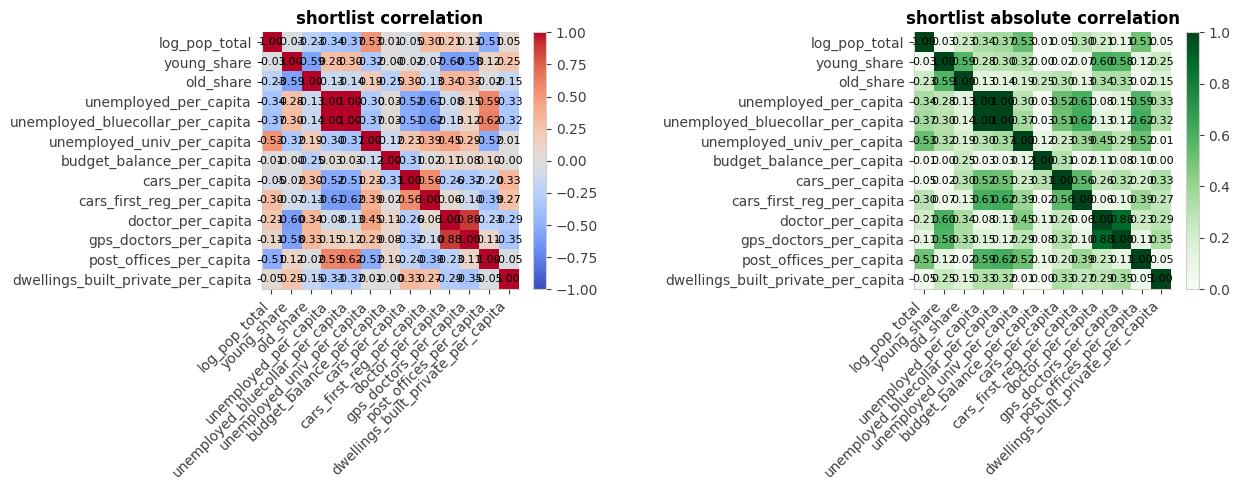

In [14]:
# this block builds or checks a smaller shortlist of variables for later modelling.
shortlist_panel = predictor_source[
    predictor_source["year"].isin(full_history_years + [2026])
].copy()

shortlist_corr = shortlist_panel[preliminary_structure_shortlist].corr()
shortlist_abs_corr = shortlist_corr.abs()

shortlist_pair_rows = []
for i, left in enumerate(preliminary_structure_shortlist):
    for right in preliminary_structure_shortlist[i + 1:]:
        shortlist_pair_rows.append(
            {
                "left_feature": left,
                "right_feature": right,
                "pair_corr": float(shortlist_corr.loc[left, right]),
                "abs_pair_corr": float(shortlist_abs_corr.loc[left, right]),
            }
        )

shortlist_pairs = (
    pd.DataFrame(shortlist_pair_rows)
    .sort_values("abs_pair_corr", ascending=False)
    .reset_index(drop=True)
)

display(shortlist_corr.round(3))
display(shortlist_abs_corr.round(3))
display(shortlist_pairs.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(shortlist_corr.values, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_title("shortlist correlation")
axes[0].set_xticks(range(len(preliminary_structure_shortlist)))
axes[0].set_yticks(range(len(preliminary_structure_shortlist)))
axes[0].set_xticklabels(preliminary_structure_shortlist, rotation=45, ha="right")
axes[0].set_yticklabels(preliminary_structure_shortlist)
for i in range(len(preliminary_structure_shortlist)):
    for j in range(len(preliminary_structure_shortlist)):
        axes[0].text(j, i, f"{shortlist_corr.values[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

im1 = axes[1].imshow(shortlist_abs_corr.values, cmap="Greens", vmin=0, vmax=1)
axes[1].set_title("shortlist absolute correlation")
axes[1].set_xticks(range(len(preliminary_structure_shortlist)))
axes[1].set_yticks(range(len(preliminary_structure_shortlist)))
axes[1].set_xticklabels(preliminary_structure_shortlist, rotation=45, ha="right")
axes[1].set_yticklabels(preliminary_structure_shortlist)
for i in range(len(preliminary_structure_shortlist)):
    for j in range(len(preliminary_structure_shortlist)):
        axes[1].text(j, i, f"{shortlist_abs_corr.values[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# clean up temporary variables, keep only shortlist_panel for the next block
for var in [
    "axes",
    "fig",
    "i",
    "im0",
    "im1",
    "j",
    "left",
    "right",
    "shortlist_abs_corr",
    "shortlist_corr",
    "shortlist_pair_rows",
    "shortlist_pairs",
]:
    if var in locals():
        del locals()[var]
del var


Interpretation. Very high correlations suggest the variables carry overlapping information.


### Refined shortlist after the first correlation look

Before defining the later model groups, I remove three variables that look too close to variables already on the list:

- `gps_doctors_per_capita`
- `unemployed_bluecollar_per_capita`
- `post_offices_per_capita`

Then I show the correlation tables again for the refined shortlist.

Removed before model grouping:
['gps_doctors_per_capita', 'unemployed_bluecollar_per_capita', 'post_offices_per_capita']

Refined shortlist:
['log_pop_total', 'young_share', 'old_share', 'unemployed_per_capita', 'unemployed_univ_per_capita', 'budget_balance_per_capita', 'cars_per_capita', 'cars_first_reg_per_capita', 'doctor_per_capita', 'dwellings_built_private_per_capita']


,log_pop_total,young_share,old_share,unemployed_per_capita,unemployed_univ_per_capita,budget_balance_per_capita,cars_per_capita,cars_first_reg_per_capita,doctor_per_capita,dwellings_built_private_per_capita
log_pop_total,1.000,-0.028,-0.225,-0.337,0.530,0.012,-0.047,0.297,0.211,0.054
young_share,-0.028,1.000,-0.586,0.276,-0.317,-0.003,-0.020,-0.068,-0.602,0.248
old_share,-0.225,-0.586,1.000,-0.129,0.194,-0.245,0.297,-0.126,0.341,-0.153
unemployed_per_capita,-0.337,0.276,-0.129,1.000,-0.297,0.028,-0.524,-0.609,-0.083,-0.327
unemployed_univ_per_capita,0.530,-0.317,0.194,-0.297,1.000,-0.119,0.228,0.388,0.449,0.007
budget_balance_per_capita,0.012,-0.003,-0.245,0.028,-0.119,1.000,-0.305,0.015,0.107,-0.003
cars_per_capita,-0.047,-0.020,0.297,-0.524,0.228,-0.305,1.000,0.558,-0.260,0.328
cars_first_reg_per_capita,0.297,-0.068,-0.126,-0.609,0.388,0.015,0.558,1.000,0.059,0.269
doctor_per_capita,0.211,-0.602,0.341,-0.083,0.449,0.107,-0.260,0.059,1.000,-0.286
dwellings_built_private_per_capita,0.054,0.248,-0.153,-0.327,0.007,-0.003,0.328,0.269,-0.286,1.000


,log_pop_total,young_share,old_share,unemployed_per_capita,unemployed_univ_per_capita,budget_balance_per_capita,cars_per_capita,cars_first_reg_per_capita,doctor_per_capita,dwellings_built_private_per_capita
log_pop_total,1.000,0.028,0.225,0.337,0.530,0.012,0.047,0.297,0.211,0.054
young_share,0.028,1.000,0.586,0.276,0.317,0.003,0.020,0.068,0.602,0.248
old_share,0.225,0.586,1.000,0.129,0.194,0.245,0.297,0.126,0.341,0.153
unemployed_per_capita,0.337,0.276,0.129,1.000,0.297,0.028,0.524,0.609,0.083,0.327
unemployed_univ_per_capita,0.530,0.317,0.194,0.297,1.000,0.119,0.228,0.388,0.449,0.007
budget_balance_per_capita,0.012,0.003,0.245,0.028,0.119,1.000,0.305,0.015,0.107,0.003
cars_per_capita,0.047,0.020,0.297,0.524,0.228,0.305,1.000,0.558,0.260,0.328
cars_first_reg_per_capita,0.297,0.068,0.126,0.609,0.388,0.015,0.558,1.000,0.059,0.269
doctor_per_capita,0.211,0.602,0.341,0.083,0.449,0.107,0.260,0.059,1.000,0.286
dwellings_built_private_per_capita,0.054,0.248,0.153,0.327,0.007,0.003,0.328,0.269,0.286,1.000


,left_feature,right_feature,pair_corr,abs_pair_corr
0,unemployed_per_capita,cars_first_reg_per_capita,-0.609,0.609
1,young_share,doctor_per_capita,-0.602,0.602
2,young_share,old_share,-0.586,0.586
3,cars_per_capita,cars_first_reg_per_capita,0.558,0.558
4,log_pop_total,unemployed_univ_per_capita,0.530,0.530
5,unemployed_per_capita,cars_per_capita,-0.524,0.524
6,unemployed_univ_per_capita,doctor_per_capita,0.449,0.449
7,unemployed_univ_per_capita,cars_first_reg_per_capita,0.388,0.388
8,old_share,doctor_per_capita,0.341,0.341
9,log_pop_total,unemployed_per_capita,-0.337,0.337


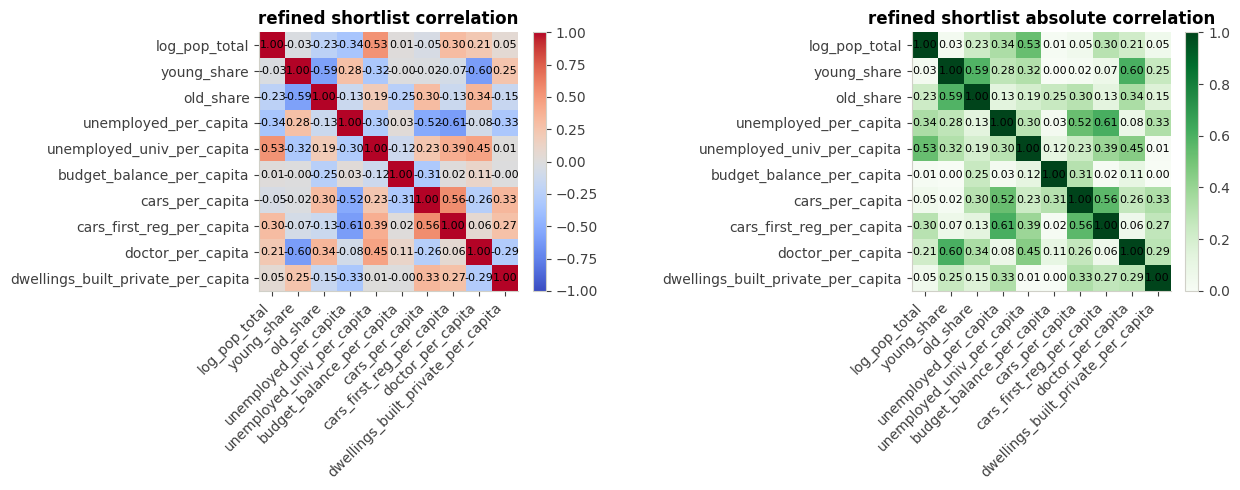

In [15]:
# this block builds or checks a smaller shortlist of variables for later modelling.
refined_drop_features = [
    "gps_doctors_per_capita",
    "unemployed_bluecollar_per_capita",
    "post_offices_per_capita"
]

refined_preliminary_structure_shortlist = [
    feature for feature in preliminary_structure_shortlist
    if feature not in refined_drop_features
]

print("Removed before model grouping:")
print(refined_drop_features)
print()
print("Refined shortlist:")
print(refined_preliminary_structure_shortlist)

refined_shortlist_corr = shortlist_panel[refined_preliminary_structure_shortlist].corr()
refined_shortlist_abs_corr = refined_shortlist_corr.abs()

refined_shortlist_pair_rows = []
for i, left in enumerate(refined_preliminary_structure_shortlist):
    for right in refined_preliminary_structure_shortlist[i + 1:]:
        refined_shortlist_pair_rows.append(
            {
                "left_feature": left,
                "right_feature": right,
                "pair_corr": float(refined_shortlist_corr.loc[left, right]),
                "abs_pair_corr": float(refined_shortlist_abs_corr.loc[left, right]),
            }
        )

refined_shortlist_pairs = (
    pd.DataFrame(refined_shortlist_pair_rows)
    .sort_values("abs_pair_corr", ascending=False)
    .reset_index(drop=True)
)

display(refined_shortlist_corr.round(3))
display(refined_shortlist_abs_corr.round(3))
display(refined_shortlist_pairs.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(refined_shortlist_corr.values, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_title("refined shortlist correlation")
axes[0].set_xticks(range(len(refined_preliminary_structure_shortlist)))
axes[0].set_yticks(range(len(refined_preliminary_structure_shortlist)))
axes[0].set_xticklabels(refined_preliminary_structure_shortlist, rotation=45, ha="right")
axes[0].set_yticklabels(refined_preliminary_structure_shortlist)
for i in range(len(refined_preliminary_structure_shortlist)):
    for j in range(len(refined_preliminary_structure_shortlist)):
        axes[0].text(j, i, f"{refined_shortlist_corr.values[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

im1 = axes[1].imshow(refined_shortlist_abs_corr.values, cmap="Greens", vmin=0, vmax=1)
axes[1].set_title("refined shortlist absolute correlation")
axes[1].set_xticks(range(len(refined_preliminary_structure_shortlist)))
axes[1].set_yticks(range(len(refined_preliminary_structure_shortlist)))
axes[1].set_xticklabels(refined_preliminary_structure_shortlist, rotation=45, ha="right")
axes[1].set_yticklabels(refined_preliminary_structure_shortlist)
for i in range(len(refined_preliminary_structure_shortlist)):
    for j in range(len(refined_preliminary_structure_shortlist)):
        axes[1].text(j, i, f"{refined_shortlist_abs_corr.values[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# clean up temporary variables, keep only the refined shortlist objects
for var in [
    "axes",
    "fig",
    "i",
    "im0",
    "im1",
    "j",
    "left",
    "right",
    "refined_shortlist_abs_corr",
    "refined_shortlist_corr",
    "refined_shortlist_pair_rows",
    "refined_shortlist_pairs",
]:
    if var in locals():
        del locals()[var]
del var


Interpretation. Very high correlations suggest the variables carry overlapping information.


### Selected variables and their descriptive statistics

This block saves the result so it can be reused later in the project.


In [16]:
# this block saves the result so it can be reused later in the project.
feature_label_map = globals().get(
    "missingness_feature_labels",
    {
        "log_pop_total": "Log population",
        "young_share": "Age 0--14 share",
        "old_share": "Age 65+ share",
        "perm_population_share": "Permanent population share",
        "perm_0_14_female_share": "Permanent female age 0--14 share",
        "perm_65_plus_female_share": "Permanent female age 65+ share",
        "perm_0_14_male_share": "Permanent male age 0--14 share",
        "perm_65_plus_male_share": "Permanent male age 65+ share",
        "perm_0_24_share": "Permanent age 0--24 share",
        "budget_revenue_per_capita": "Budget revenue per 1,000 residents",
        "budget_expenditure_per_capita": "Budget expenditure per 1,000 residents",
        "dwellings_per_capita": "Dwellings built per 1,000 residents",
        "dwellings_terminated_per_capita": "Dwellings terminated per 1,000 residents",
        "dwellings_built_muni_per_capita": "Municipal dwellings built per 1,000 residents",
        "dwellings_built_private_per_capita": "Private dwellings built per 1,000 residents",
        "gps_doctors_per_capita": "General practitioners per 1,000 residents",
        "pediatric_doctors_per_capita": "Pediatric doctors per 1,000 residents",
        "cars_per_capita": "Cars per 1,000 residents",
        "internet_other_per_capita": "Other internet subscriptions per 1,000 residents",
        "tv_subs_per_capita": "TV subscriptions per 1,000 residents",
        "cars_first_reg_per_capita": "New car registrations per 1,000 residents",
        "post_offices_per_capita": "Post offices per 1,000 residents",
        "internet_per_capita": "Internet subscriptions per 1,000 residents",
        "internet_xdsl_per_capita": "xDSL internet subscriptions per 1,000 residents",
        "internet_cable_per_capita": "Cable internet subscriptions per 1,000 residents",
        "internet_optical_per_capita": "Optical internet subscriptions per 1,000 residents",
        "unemployed_per_capita": "Unemployed people per 1,000 residents",
        "unemployed_180_plus_per_capita": "Unemployed 180+ days per 1,000 residents",
        "unemployed_univ_per_capita": "University-educated unemployed per 1,000 residents",
        "unemployed_bluecollar_per_capita": "Blue-collar unemployed per 1,000 residents",
        "unemployed_young_per_capita": "Young unemployed per 1,000 residents",
        "unemployed_365_plus_per_capita": "Unemployed 365+ days per 1,000 residents",
        "nominal_income_per_capita": "Nominal labour income per 1,000 residents",
        "real_income_per_capita": "Real labour income per 1,000 residents",
        "doctor_per_capita": "Doctors per 1,000 residents",
        "budget_balance_per_capita": "Budget balance per 1,000 residents",
        "cpi": "Consumer price index",
    },
)

descriptive_stats_rows = []
summary_source = predictor_source[predictor_source["year"].isin(full_history_years + [2026])].copy()
for feature in refined_preliminary_structure_shortlist:
    series = pd.to_numeric(summary_source[feature], errors="coerce").dropna()
    descriptive_stats_rows.append(
        {
            "feature": feature,
            "Mean": float(series.mean()) if len(series) else np.nan,
            "Median": float(series.median()) if len(series) else np.nan,
            "SD": float(series.std()) if len(series) else np.nan,
            "Min": float(series.min()) if len(series) else np.nan,
            "Max": float(series.max()) if len(series) else np.nan,
        }
    )

descriptive_stats = pd.DataFrame(descriptive_stats_rows)

missingness_latex_table = (
    feature_missingness[feature_missingness["feature"].isin(refined_preliminary_structure_shortlist)]
    .drop(columns=["recommendation"])
    .merge(descriptive_stats, on="feature", how="left")
    .assign(
        feature=lambda df: df["feature"].map(
            lambda value: feature_label_map.get(
                value,
                value.replace("_", " ").title(),
            )
        )
    )
    .rename(
        columns={
            "feature": "Feature",
            "nonmissing_2018": "2018 NA",
            "nonmissing_2019": "2019 NA",
            "nonmissing_2022": "2022 NA",
            "nonmissing_2024": "2024 NA",
            "nonmissing_2026": "2026 NA",
        }
    )
    .sort_values("Feature")
)

missingness_latex_display = missingness_latex_table.copy()
for col in ["2018 NA", "2019 NA", "2022 NA", "2024 NA", "2026 NA"]:
    missingness_latex_display[col] = missingness_latex_display[col].map(
        lambda value: f"{100 * value:.1f}\%"
    )
for col in ["Mean", "Median", "SD", "Min", "Max"]:
    missingness_latex_display[col] = missingness_latex_display[col].map(
        lambda value: "" if pd.isna(value) else f"{value:.3f}"
    )

missingness_latex_string = missingness_latex_display.to_latex(
    index=False,
    escape=False,
    caption="Non-missing share and pooled descriptive statistics of the refined shortlisted structural predictors",
    label="tab:refined_structure_predictor_stats",
    column_format="lcccccccccc",
)
missingness_latex_string = missingness_latex_string.replace(
    "\\begin{tabular}{lcccccccccc}",
    "\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}{lcccccccccc}",
)
missingness_latex_string = missingness_latex_string.replace(
    "\\end{tabular}",
    "\\end{tabular}%\n}",
)

if "project_root" not in locals():
    try:
        here = Path(__file__).resolve().parent
    except NameError:
        here = Path.cwd()

    project_root = here
    while not (project_root / "data").exists() and project_root != project_root.parent:
        project_root = project_root.parent

missingness_output_paths = [
    project_root / "graphs_tables" / "refined_structure_predictor_stats_table.tex",
    project_root / "doc" / "ÚJLaTex_ENGLISH_Template másolat 2" / "figures" / "refined_structure_predictor_stats_table.tex",
]
for output_path in missingness_output_paths:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(missingness_latex_string, encoding="utf-8")

display(missingness_latex_display)
print(missingness_latex_string)
print("Saved LaTeX table to:")
for output_path in missingness_output_paths:
    print(output_path)

for var in [
    "col",
    "descriptive_stats",
    "descriptive_stats_rows",
    "feature_label_map",
    "missingness_latex_display",
    "missingness_latex_string",
    "missingness_latex_table",
    "missingness_output_paths",
    "series",
    "summary_source",
    "output_path",
]:
    if var in locals():
        del locals()[var]
del var


,Feature,2018 NA,2019 NA,2022 NA,2024 NA,2026 NA,Mean,Median,SD,Min,Max
9,Age 0--14 share,100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,0.145,0.143,0.016,0.089,0.188
6,Age 65+ share,100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,0.199,0.198,0.023,0.143,0.258
0,"Budget balance per 1,000 residents",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,5063.587,2933.861,65991.261,-413058.207,534617.354
2,"Cars per 1,000 residents",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,395.535,394.152,64.516,224.710,676.379
3,"Doctors per 1,000 residents",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,0.609,0.605,0.086,0.387,0.851
5,Log population,100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,11.416,11.417,0.114,11.107,11.683
1,"New car registrations per 1,000 residents",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,31.351,29.466,12.636,12.117,105.306
4,"Private dwellings built per 1,000 residents",100.0\%,100.0\%,100.0\%,99.1\%,99.1\%,0.756,0.468,0.885,0.000,6.762
7,"Unemployed people per 1,000 residents",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,26.924,22.318,16.866,5.266,91.827
8,"University-educated unemployed per 1,000 resid...",100.0\%,100.0\%,100.0\%,100.0\%,100.0\%,0.762,0.608,0.524,0.125,2.882


\begin{table}
\caption{Non-missing share and pooled descriptive statistics of the refined shortlisted structural predictors}
\label{tab:refined_structure_predictor_stats}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccccc}
\toprule
Feature & 2018 NA & 2019 NA & 2022 NA & 2024 NA & 2026 NA & Mean & Median & SD & Min & Max \\
\midrule
Age 0--14 share & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 0.145 & 0.143 & 0.016 & 0.089 & 0.188 \\
Age 65+ share & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 0.199 & 0.198 & 0.023 & 0.143 & 0.258 \\
Budget balance per 1,000 residents & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 5063.587 & 2933.861 & 65991.261 & -413058.207 & 534617.354 \\
Cars per 1,000 residents & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 395.535 & 394.152 & 64.516 & 224.710 & 676.379 \\
Doctors per 1,000 residents & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 100.0\% & 0.609 & 0.605 & 0.086 & 0.387 & 0.851 \\
Log population & 100.0\% & 100.0\% & 100.0\% & 

Interpretation. Lower coverage means the variable is harder to use safely without imputation.


### Selected variables and their correlation matrix

Drop selected variables before building the final shortlist.


Removed before model grouping:
['gps_doctors_per_capita', 'unemployed_bluecollar_per_capita', 'post_offices_per_capita']

Refined shortlist:
['log_pop_total', 'young_share', 'old_share', 'unemployed_per_capita', 'unemployed_univ_per_capita', 'budget_balance_per_capita', 'cars_per_capita', 'cars_first_reg_per_capita', 'doctor_per_capita', 'dwellings_built_private_per_capita']


,Log population,Age 0--14 share,Age 65+ share,"Unemployed people per 1,000 residents","University-educated unemployed per 1,000 residents","Budget balance per 1,000 residents","Cars per 1,000 residents","New car registrations per 1,000 residents","Doctors per 1,000 residents","Private dwellings built per 1,000 residents"
Log population,1.000,-0.028,-0.225,-0.337,0.530,0.012,-0.047,0.297,0.211,0.054
Age 0--14 share,-0.028,1.000,-0.586,0.276,-0.317,-0.003,-0.020,-0.068,-0.602,0.248
Age 65+ share,-0.225,-0.586,1.000,-0.129,0.194,-0.245,0.297,-0.126,0.341,-0.153
"Unemployed people per 1,000 residents",-0.337,0.276,-0.129,1.000,-0.297,0.028,-0.524,-0.609,-0.083,-0.327
"University-educated unemployed per 1,000 residents",0.530,-0.317,0.194,-0.297,1.000,-0.119,0.228,0.388,0.449,0.007
"Budget balance per 1,000 residents",0.012,-0.003,-0.245,0.028,-0.119,1.000,-0.305,0.015,0.107,-0.003
"Cars per 1,000 residents",-0.047,-0.020,0.297,-0.524,0.228,-0.305,1.000,0.558,-0.260,0.328
"New car registrations per 1,000 residents",0.297,-0.068,-0.126,-0.609,0.388,0.015,0.558,1.000,0.059,0.269
"Doctors per 1,000 residents",0.211,-0.602,0.341,-0.083,0.449,0.107,-0.260,0.059,1.000,-0.286
"Private dwellings built per 1,000 residents",0.054,0.248,-0.153,-0.327,0.007,-0.003,0.328,0.269,-0.286,1.000


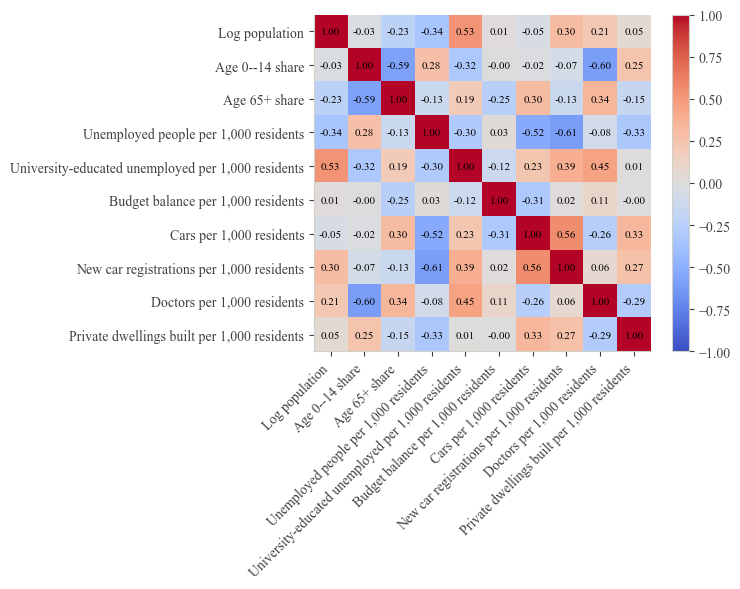

Saved correlation figure to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/graphs_tables/refined_structure_shortlist_corr.png
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/doc/ÚjLaTex_ENGLISH_Template másolat 2/figures/refined_structure_shortlist_corr.png


In [17]:
# drop selected variables before building the final shortlist
refined_drop_features = [
    "gps_doctors_per_capita",
    "unemployed_bluecollar_per_capita",
    "post_offices_per_capita",
]

refined_preliminary_structure_shortlist = [
    feature for feature in preliminary_structure_shortlist
    if feature not in refined_drop_features
]

print("Removed before model grouping:")
print(refined_drop_features)
print()
print("Refined shortlist:")
print(refined_preliminary_structure_shortlist)

# readable labels for selected variables
feature_name_map = {
    "young_share": "Age 0--14 share",
    "old_share": "Age 65+ share",
    "budget_balance_per_capita": "Budget balance per 1,000 residents",
    "cars_per_capita": "Cars per 1,000 residents",
    "doctor_per_capita": "Doctors per 1,000 residents",
    "log_pop_total": "Log population",
    "cars_first_reg_per_capita": "New car registrations per 1,000 residents",
    "dwellings_built_private_per_capita": "Private dwellings built per 1,000 residents",
    "unemployed_per_capita": "Unemployed people per 1,000 residents",
    "unemployed_univ_per_capita": "University-educated unemployed per 1,000 residents",
}

pretty_feature_names = [
    feature_name_map.get(feature, feature)
    for feature in refined_preliminary_structure_shortlist
]

# keep only the shortlisted variables and compute the correlation matrix
refined_shortlist_corr = shortlist_panel[refined_preliminary_structure_shortlist].corr()

# rename rows and columns for display
refined_shortlist_corr_display = refined_shortlist_corr.copy()
refined_shortlist_corr_display.index = pretty_feature_names
refined_shortlist_corr_display.columns = pretty_feature_names

# display the correlation table
display(refined_shortlist_corr_display.round(3))

# find project root and output path
if "project_root" not in locals():
    try:
        here = Path(__file__).resolve().parent
    except NameError:
        here = Path.cwd()

    project_root = here
    while not (project_root / "data").exists() and project_root != project_root.parent:
        project_root = project_root.parent

output_fig_paths = [
    project_root / "graphs_tables" / "refined_structure_shortlist_corr.png",
    project_root / "doc" / "ÚJLaTex_ENGLISH_Template másolat 2" / "figures" / "refined_structure_shortlist_corr.png",
]
for output_fig_path in output_fig_paths:
    output_fig_path.parent.mkdir(parents=True, exist_ok=True)

# plot only the plain correlation table, with scale from -1 to 1 and no title
plt.rcParams["font.family"] = "Times New Roman"
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(refined_shortlist_corr.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(pretty_feature_names)))
ax.set_yticks(range(len(pretty_feature_names)))
ax.set_xticklabels(pretty_feature_names, rotation=45, ha="right")
ax.set_yticklabels(pretty_feature_names)

for i in range(len(pretty_feature_names)):
    for j in range(len(pretty_feature_names)):
        ax.text(
            j,
            i,
            f"{refined_shortlist_corr.values[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8,
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
for output_fig_path in output_fig_paths:
    plt.savefig(output_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved correlation figure to:")
for output_fig_path in output_fig_paths:
    print(output_fig_path)

# clean up
for var in [
    "ax",
    "fig",
    "feature_name_map",
    "here",
    "i",
    "im",
    "j",
    "output_fig_path",
    "output_fig_paths",
    "pretty_feature_names",
    "refined_drop_features",
    "refined_shortlist_corr",
    "refined_shortlist_corr_display",
]:
    if var in locals():
        del locals()[var]
del var


Interpretation. Very high correlations suggest the variables carry overlapping information.


### Preliminary model groups for later testing

I am not fitting models here yet.
I only group the pre-screened fundamentals into four nested bundles for later modelling tests:

- `model_1_demography_only`
- `model_2_plus_core_economy`
- `model_3_plus_modernization`
- `model_4_plus_public_service_housing`

In [18]:
# this block saves the result so it can be reused later in the project.
fundamentals_model_bundles = {
    "model_1_demography_only": [
        "log_pop_total",
        "young_share",
        "old_share",
    ],
    "model_2_plus_core_economy": [
        "log_pop_total",
        "young_share",
        "old_share",
        "unemployed_per_capita",
        "unemployed_univ_per_capita",
        "budget_balance_per_capita",
    ],
    "model_3_plus_modernization": [
        "log_pop_total",
        "young_share",
        "old_share",
        "unemployed_per_capita",
        "unemployed_univ_per_capita",
        "budget_balance_per_capita",
        "cars_per_capita",
        "cars_first_reg_per_capita",
    ],
    "model_4_plus_public_service_housing": [
        "log_pop_total",
        "young_share",
        "old_share",
        "unemployed_per_capita",
        "unemployed_univ_per_capita",
        "budget_balance_per_capita",
        "cars_per_capita",
        "cars_first_reg_per_capita",
        "doctor_per_capita",
        "dwellings_built_private_per_capita",
    ],
}

fundamentals_bundle_summary = pd.DataFrame(
    {
        "scenario": list(fundamentals_model_bundles.keys()),
        "feature_count": [len(features) for features in fundamentals_model_bundles.values()],
        "features": [", ".join(features) for features in fundamentals_model_bundles.values()],
    }
)

fundamentals_bundle_rows = []
for scenario, features in fundamentals_model_bundles.items():
    for year in full_history_years + [2026]:
        sub = predictor_source[predictor_source["year"] == year].copy()
        complete_mask = sub[features].notna().all(axis=1)
        fundamentals_bundle_rows.append(
            {
                "scenario": scenario,
                "year": year,
                "feature_count": len(features),
                "complete_rows": int(complete_mask.sum()),
                "complete_case_share": float(complete_mask.mean()),
            }
        )

fundamentals_bundle_coverage = pd.DataFrame(fundamentals_bundle_rows)
fundamentals_bundle_share_table = (
    fundamentals_bundle_coverage
    .pivot(index="scenario", columns="year", values="complete_case_share")
    .reset_index()
)
fundamentals_bundle_count_table = (
    fundamentals_bundle_coverage
    .pivot(index="scenario", columns="year", values="complete_rows")
    .reset_index()
)

display(fundamentals_bundle_summary)
display(fundamentals_bundle_share_table.round(3))
display(fundamentals_bundle_count_table)

import json
from pathlib import Path

output_root = Path.cwd()
while not (output_root / "data").exists() and output_root != output_root.parent:
    output_root = output_root.parent

screened_feature_output_path = output_root / "data" / "created" / "screened_feature_sets.json"
if screened_feature_output_path.exists():
    screened_feature_export = json.loads(screened_feature_output_path.read_text(encoding="utf-8"))
else:
    screened_feature_export = {}

if "refined_drop_features" in locals():
    structure_exclusion_features = list(refined_drop_features)
else:
    structure_exclusion_features = [
        feature
        for feature in preliminary_structure_shortlist
        if feature not in refined_preliminary_structure_shortlist
    ]

legacy_media_config_keys = [
    "screened_recent_media_extension",
    "selected_single_media_outlet",
]
for legacy_media_config_key in legacy_media_config_keys:
    screened_feature_export.pop(legacy_media_config_key, None)

screened_feature_export.update(
    {
        "screened_full_history_structure": refined_preliminary_structure_shortlist,
        "preliminary_fundamentals_models": fundamentals_model_bundles,
        "manual_structure_exclusions": {
            feature: "Removed after the first shortlist correlation check because it looked too redundant."
            for feature in structure_exclusion_features
        },
    }
)

screened_feature_output_path.parent.mkdir(parents=True, exist_ok=True)
screened_feature_output_path.write_text(
    json.dumps(screened_feature_export, indent=2),
    encoding="utf-8",
)

print("Saved preliminary feature config to:")
print(screened_feature_output_path)

# clean up temporary variables, keep only the final exported screening choices
for var in [
    "complete_mask",
    "features",
    "fundamentals_bundle_count_table",
    "fundamentals_bundle_coverage",
    "fundamentals_bundle_rows",
    "fundamentals_bundle_share_table",
    "fundamentals_bundle_summary",
    "legacy_media_config_keys",
    "scenario",
    "screened_feature_export",
    "screened_feature_output_path",
    "structure_exclusion_features",
    "sub",
    "year",
]:
    if var in locals():
        del locals()[var]
del var


,scenario,feature_count,features
0,model_1_demography_only,3,"log_pop_total, young_share, old_share"
1,model_2_plus_core_economy,6,"log_pop_total, young_share, old_share, unemplo..."
2,model_3_plus_modernization,8,"log_pop_total, young_share, old_share, unemplo..."
3,model_4_plus_public_service_housing,10,"log_pop_total, young_share, old_share, unemplo..."


year,scenario,2018,2019,2022,2024,2026
0,model_1_demography_only,1.0,1.0,1.0,1.000,1.000
1,model_2_plus_core_economy,1.0,1.0,1.0,1.000,1.000
2,model_3_plus_modernization,1.0,1.0,1.0,1.000,1.000
3,model_4_plus_public_service_housing,1.0,1.0,1.0,0.991,0.991


year,scenario,2018,2019,2022,2024,2026
0,model_1_demography_only,106,106,106,106,106
1,model_2_plus_core_economy,106,106,106,106,106
2,model_3_plus_modernization,106,106,106,106,106
3,model_4_plus_public_service_housing,106,106,106,105,105


Saved preliminary feature config to:
/Users/andrasikristof/Documents/Egyetem/2026:27 - 2. félév/Election_predictions/data/created/screened_feature_sets.json


### Easy English interpretation of the preliminary screening

This final section is still only exploratory.
It does **not** fit prediction models yet.

**Table 1: manual shortlist after the NA check**

- `feature` = the kept variable
- `model_block` = which later bundle it belongs to
- `why_keep` = the simple manual reason for keeping it
- `min_nonmissing_share` = the weakest yearly non-missing share
- `coverage_note` = quick human summary of the coverage

Why these variables stayed:

- they passed the strong NA filter, or were very close to it
- they are easy to interpret
- they keep the shortlist short enough for a first pass

**Table 2 and 3: correlation tables**

- signed correlation shows direction
- absolute correlation shows only how similar two predictors are
- very large values mean the two variables may be close substitutes later

**Table 4: sorted pair list**

- this is the same correlation idea, but sorted from the most redundant pair to the least redundant pair

**Refined shortlist step**

- after the first correlation look, `gps_doctors_per_capita` and `unemployed_bluecollar_per_capita` are removed
- then the correlation tables are shown again for the refined shortlist

**Table 5: preliminary model bundles**

- these are not fitted models yet
- they are only four nested predictor groups prepared for later testing

**Table 6 and 7: bundle coverage tables**

- they show how many districts would stay usable if all predictors in that bundle had to be present together
- this is still an NA/completeness check, not a performance result

Bottom line:

- the notebook now stops at a clean pre-screen
- income and internet variables were not kept because their coverage stayed around `85%`
- the shortlist keeps broad demographic, economic, modernization, and service variables without moving into model fitting
- `gps_doctors_per_capita`, `unemployed_bluecollar_per_capita`, and `post_offices_per_capita` were dropped after the correlation check to keep the final shortlist less redundant
- `dwellings_built_private_per_capita` is the only nearly-complete variable here, so the last bundle may drop to `105/106` in `2024` and `2026`

### 2026 Political Bloc Analysis

This block saves the result so it can be reused later in the project.


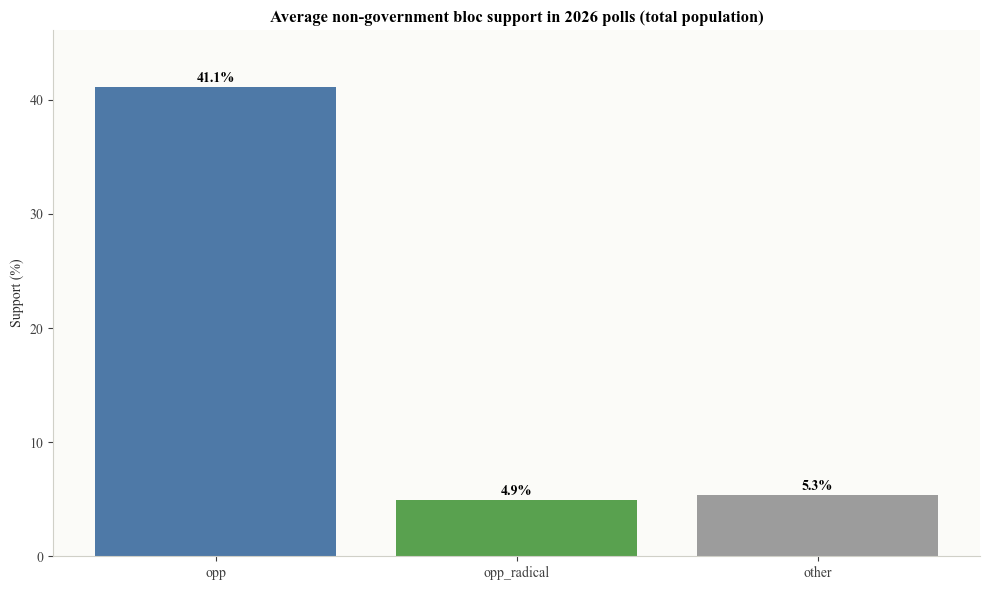

In [19]:
# this block prepares a 2026 bloc summary for inspection.
# it is intentionally not exported because this summary is not used in the LaTeX thesis.

from pathlib import Path

# 1. Filter the 'polls' dataframe for polls in 2026 where 'Adatok.bázisa' is 'Összes'.
polls_2026_total = polls.copy()
# keep only rows where Fókusz is missing
polls_2026_total = polls_2026_total[
    polls_2026_total["Fókusz"].isna()
].copy()

# Ensure 'Vég' is datetime
polls_2026_total["Vég"] = pd.to_datetime(polls_2026_total["Vég"], errors="coerce")
# Filter for year 2026 and 'Összes' voters
polls_2026_total = polls_2026_total[
    (polls_2026_total["Vég"].dt.year == 2026)
    & (polls_2026_total["Adatok.bázisa"] == "Összes")
].copy()

# 2. Rebuild the 2026 blocs using the same mapping as the full-pipeline notebooks.
poll_block_map_2026_nat = {
    "Fidesz": "gov",
    "TISZA": "opp",
    "MH": "opp_radical",
    "DK": "other",
    "MSZP": "other",
    "P": "other",
    "MM": "other",
    "DK-MSZP-P": "other",
    "MSZP-P": "other",
    "MMN": "other",
    "NP": "other",
    "EM": "other",
    "Együtt": "other",
    "LMP": "other",
    "MKKP": "other",
    "2RK": "other",
    "Jobbik": "other",
    "Egyéb párt": "other",
}
block_cols = ["gov", "opp", "opp_radical", "other"]
display_blocks = ["opp", "opp_radical", "other"]

for col in poll_block_map_2026_nat:
    if col not in polls_2026_total.columns:
        polls_2026_total[col] = 0.0
    polls_2026_total[col] = pd.to_numeric(polls_2026_total[col], errors="coerce").fillna(0.0)

for block in block_cols:
    party_cols = [col for col, mapped in poll_block_map_2026_nat.items() if mapped == block]
    polls_2026_total[block] = polls_2026_total[party_cols].sum(axis=1)

mean_support = polls_2026_total[display_blocks].mean().reset_index()
mean_support.columns = ["Bloc", "Average Support"]

block_colors = {
    "gov": "#f28e2b",
    "opp": "#4e79a7",
    "opp_radical": "#59a14f",
    "other": "#9c9c9c",
}
colors = [block_colors[bloc] for bloc in mean_support["Bloc"]]

# 3. Create a bar chart showing the average non-government bloc support.
plt.figure(figsize=(10, 6))
bars = plt.bar(mean_support["Bloc"], mean_support["Average Support"], color=colors)

# 4. Add text labels on top of the bars with the percentage values.
for bar in bars:
    yval = bar.get_height()
    if not pd.isna(yval):
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.2, f"{yval:.1f}%", ha="center", va="bottom", fontweight="bold")

plt.title("Average non-government bloc support in 2026 polls (total population)")
plt.ylabel("Support (%)")
# Set ylim with a bit of headspace
max_val = mean_support["Average Support"].max() if not mean_support["Average Support"].empty else 0
plt.ylim(0, max(max_val, 10) + 5)
plt.tight_layout()
plt.show()

print("This summary is not exported because it is not used in the LaTeX thesis.")

# Clean up
for var in [
    "polls_2026_total", "mean_support", "colors", "bars",
    "block_cols", "display_blocks", "block_colors", "poll_block_map_2026_nat",
    "party_cols", "col", "block", "bar", "yval", "max_val"
]:
    if var in locals():
        del locals()[var]
del var


Interpretation. Read this as a descriptive snapshot of the 2026 polling picture, not as the final forecast.


### 2026 Pollster Comparison (Political Blocs)

This chart compares the non-government blocs in the latest 20 polls of 2026, using the same 2026 bloc mapping as the full-pipeline notebooks.


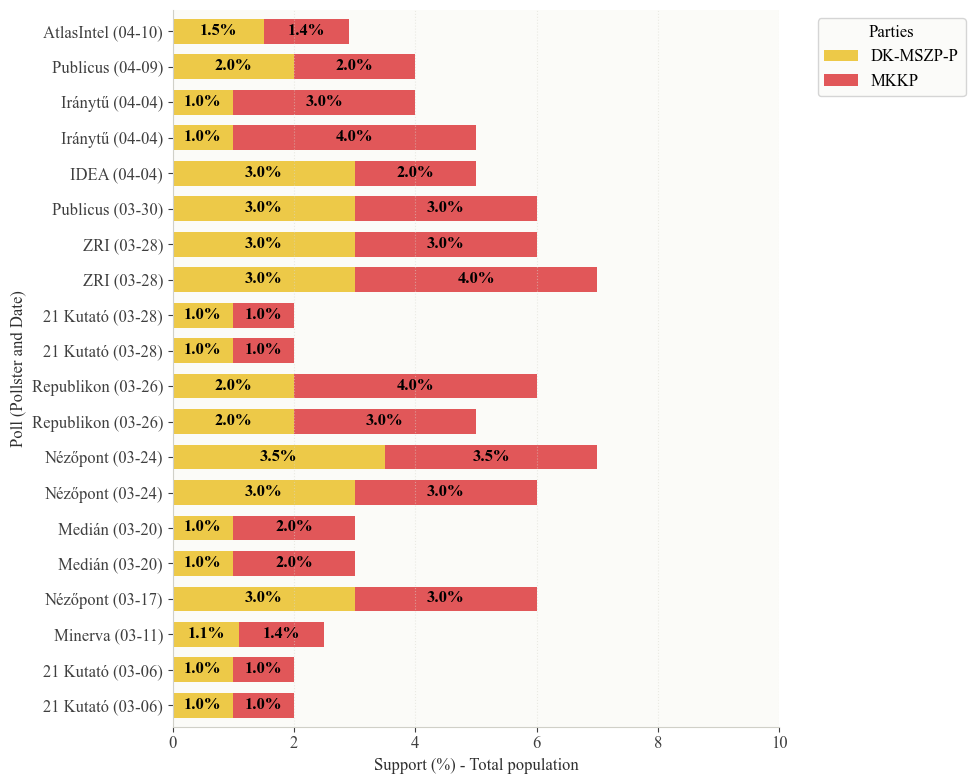

In [20]:
# this block saves the result so it can be reused later in the project.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# set global font to Times New Roman, size 12
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12

# 1. Filter 'polls' for 2026 entries where 'Adatok.bázisa' is 'Összes' and date is on/after 2026-01-01.
df_2026 = polls.copy()

# keep only rows where Fókusz is missing
df_2026 = df_2026[
    df_2026["Fókusz"].isna()
].copy()

df_2026["Vég_dt"] = pd.to_datetime(df_2026["Vég"], errors="coerce")
df_2026 = df_2026[
    (df_2026["Vég_dt"] >= "2026-01-01")
    & (df_2026["Adatok.bázisa"] == "Összes")
].copy()

# 2. Create a 'DK-MSZP-P' combined column by summing components (filling NaNs with 0).
parties_to_sum = ["DK", "MSZP", "P", "DK-MSZP-P"]
for p in parties_to_sum:
    if p not in df_2026.columns:
        df_2026[p] = 0
    df_2026[p] = pd.to_numeric(df_2026[p], errors="coerce").fillna(0)

df_2026["DK-MSZP-P_total"] = df_2026[parties_to_sum].sum(axis=1)

# Ensure MKKP is numeric
if "MKKP" not in df_2026.columns:
    df_2026["MKKP"] = 0
df_2026["MKKP"] = pd.to_numeric(df_2026["MKKP"], errors="coerce").fillna(0)

# 3. Filtering
# Exclude pollster '?'
df_2026 = df_2026[df_2026["Adatgazda"] != "?"]

# Exclude polls where both DK-MSZP-P and MKKP are 0.0
df_2026 = df_2026[~((df_2026["DK-MSZP-P_total"] == 0) & (df_2026["MKKP"] == 0))]

# Keep only the latest 20 unique polls by fieldwork end date (Vég)
df_plot = df_2026.sort_values("Vég_dt", ascending=False).head(20).copy()

# Drop original 'DK-MSZP-P' column if it exists to avoid duplicates after renaming 'DK-MSZP-P_total'
if "DK-MSZP-P" in df_plot.columns:
    df_plot = df_plot.drop(columns=["DK-MSZP-P"])

df_plot = df_plot.rename(columns={"DK-MSZP-P_total": "DK-MSZP-P"})

# Create labels: Adatgazda (MM-DD)
df_plot["Poll_Label"] = df_plot["Adatgazda"] + " (" + df_plot["Vég_dt"].dt.strftime("%m-%d") + ")"

# Reverse order for horizontal bar chart (latest at top)
df_plot = df_plot.iloc[::-1]

party_labels = ["DK-MSZP-P", "MKKP"]

# 5. Create a horizontal stacked bar chart.
# MKKP red (#e15759), DK-MSZP-P yellow (#edc948)
colors_map = {"DK-MSZP-P": "#edc948", "MKKP": "#e15759"}
colors_list = [colors_map[p] for p in party_labels]

fig, ax = plt.subplots(figsize=(10, 8))
df_plot.plot(
    x="Poll_Label",
    y=party_labels,
    kind="barh",
    stacked=True,
    color=colors_list,
    ax=ax,
    width=0.7
)

# Add labels with the percentage values inside the bars.
for container in ax.containers:
    labels = [f"{v:.1f}%" if v > 0.5 else "" for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="black",
        fontweight="bold",
        fontsize=12
    )

ax.set_xlabel("Support (%) - Total population", fontsize=12)
ax.set_ylabel("Poll (Pollster and Date)", fontsize=12)
ax.legend(title="Parties", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12, title_fontsize=12)
ax.set_xlim(0, 10)
ax.grid(axis="x", linestyle=":", alpha=0.5)
ax.tick_params(axis="both", labelsize=12)

# 7. Save the figure to the two requested export folders.
plt.tight_layout()

if "project_root" not in locals():
    try:
        here = Path(__file__).resolve().parent
    except NameError:
        here = Path.cwd()

    project_root = here
    while not (project_root / "data").exists() and project_root != project_root.parent:
        project_root = project_root.parent

figure_output_paths = [
    project_root / "graphs_tables" / "smaller_parties_polls_2026.png",
    project_root / "doc" / "ÚJLaTex_ENGLISH_Template másolat 2" / "figures" / "smaller_parties_polls_2026.png",
]
for output_fig_path in figure_output_paths:
    output_fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# 8. Also export the underlying data to a LaTeX table in both requested folders.
latex_output_paths = [
    project_root / "graphs_tables" / "smaller_parties_polls_2026.tex",
    project_root / "doc" / "ÚJLaTex_ENGLISH_Template másolat 2" / "figures" / "smaller_parties_polls_2026.tex",
]
for latex_path in latex_output_paths:
    latex_path.parent.mkdir(parents=True, exist_ok=True)

# Select only relevant columns for the LaTeX table
df_latex = df_plot[["Poll_Label"] + party_labels].copy()

latex_string = df_latex.to_latex(
    index=False,
    caption="Support for DK-MSZP-P and MKKP in the latest 20 polls of 2026 (total population)",
    label="tab:smaller_parties_polls_2026",
    float_format="%.1f"
)
for latex_path in latex_output_paths:
    latex_path.write_text(latex_string, encoding="utf-8")

print("Saved figure to:")
for output_fig_path in figure_output_paths:
    print(output_fig_path)
print()
print("Saved LaTeX table to:")
for latex_path in latex_output_paths:
    print(latex_path)

# Clean up
for var in [
    "df_2026", "df_plot", "df_latex", "latex_string", "latex_output_paths",
    "colors_list", "party_labels", "parties_to_sum", "p",
    "figure_output_paths", "colors_map", "latex_path", "output_fig_path"
]:
    if var in locals():
        del locals()[var]
del var


Interpretation. Read this as a descriptive snapshot of the 2026 polling picture, not as the final forecast.
